# Inferential Statistics 

## Inputs: `cr_long_CLEAN.csv` and `summary_CR_wide_CLEAN.csv` from eda.ipynb

### Hypotheses Tested
- H1: Effect of Noun Memorability on CR_IR
    - H1a: Subject vs Object Memorability Effects
    - H1b: OLS Regression: CR_IR ~ subject_high + object_high
- H2: Effect of Voice on CR_IR
- H3: Memorability × Voice Interaction
- H4: Effect of Memorability on WR Hit Rate
    - H4a: Voice effect on WR
    - H4b: CR_IR vs WR independence
- H5: Condition Effect on False Alarm Rate
    - H5a: Voice effect on FA 
- H6: Block × Condition Fatigue Effect
- H7: Effect of Voice on Reaction Time (RT_IR)
    - H7a: Overall voice effect
    - H7b: Voice effect within each memorability condition


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, kruskal, wilcoxon, mannwhitneyu,
                         spearmanr, pearsonr, f_oneway, ttest_1samp)
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from itertools import combinations
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

DATA_DIR   = 'Sentence Memorability/NewLogsAnonymized'
CLEAN_DIR = os.path.expanduser('BRSM_output_CLEAN')
cr_long = pd.read_csv(os.path.join(CLEAN_DIR, 'cr_long_CLEAN.csv'))
summary_w = pd.read_csv(os.path.join(CLEAN_DIR, 'summary_CR_wide_CLEAN.csv'))
bv = pd.read_csv(os.path.join(CLEAN_DIR, 'block_validity_CLEAN.csv'))
TARGET_CONDITIONS = ['HVL', 'LVH', 'LVL']
COND_ORDER = ['HVL_A','HVL_P','LVH_A','LVH_P','LVL_A','LVL_P']
N_PART = cr_long['participant_ID'].nunique()
print(f'cr_long shape : {cr_long.shape}')
print(f'summary_w shape: {summary_w.shape}')
print(f'Participants : {N_PART}')
print('\nCondition counts:')
print(cr_long.groupby(['condition','voice']).size())

cr_long shape : (672, 23)
summary_w shape: (112, 43)
Participants : 112

Condition counts:
condition  voice
HVL        A        112
           P        112
LVH        A        112
           P        112
LVL        A        112
           P        112
dtype: int64


## STEP 1 — Helper Functions

In [2]:
# ── Significance stars ────────────────────────────────────────────────────
def sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ── Shapiro-Wilk table ────────────────────────────────────────────────────
def normality_table(df, col, groupby_col, title='Shapiro-Wilk Normality Test'):
    print(f'\n=== {title} ===')
    print(f'{"Group":<15} {"N":<6} {"W":<10} {"p-value":<14} {"Normal?"}')
    print('-'*55)
    results = []
    for grp, sub in df.groupby(groupby_col):
        data = sub[col].dropna()
        if len(data) < 8: continue
        w, p = shapiro(data)
        normal = 'YES' if p > 0.05 else 'NO'
        print(f'{str(grp):<15} {len(data):<6} {w:<10.4f} {p:<14.2e} {normal}')
        results.append({'group': grp, 'n': len(data), 'W': w, 'p': p, 'normal': normal == 'YES'})
    res = pd.DataFrame(results)
    print(f'\nNormal groups: {res["normal"].sum()} / {len(res)}')
    return res

# ── Bonferroni corrected Wilcoxon pairwise ────────────────────────────────
def paired_wilcoxon_pairwise(df, col, group_col, id_col='participant_ID', alpha=0.05):
    groups = sorted(df[group_col].unique())
    pairs = list(combinations(groups, 2))
    n_comp = len(pairs)
    bonf_alpha = alpha / n_comp
    print(f'Pairwise Wilcoxon signed-rank tests ({n_comp} comparisons, Bonferroni α={bonf_alpha:.4f})')
    print(f'{"Pair":<22} {"W":<10} {"p_raw":<12} {"p_bonf":<12} {"Sig":<5} {"Direction"}')
    print('-'*75)
    rows = []
    for (g1, g2) in pairs:
        d1 = df[df[group_col]==g1].set_index(id_col)[col]
        d2 = df[df[group_col]==g2].set_index(id_col)[col]
        merged = pd.concat([d1,d2],axis=1,keys=[g1,g2]).dropna()
        if len(merged) < 8: continue
        W, p = wilcoxon(merged[g1], merged[g2])
        p_b = min(p * n_comp, 1.0)
        dirn = f'{g1}>{g2}' if merged[g1].mean() > merged[g2].mean() else f'{g2}>{g1}'
        print(f'{g1} vs {g2:<22} {W:<10.1f} {p:<12.4f} {p_b:<12.4f} {sig(p_b):<5} {dirn}')
        rows.append({'g1':g1,'g2':g2,'W':W,'p_raw':p,'p_bonf':p_b})
    return pd.DataFrame(rows)

# ── Effect size for Wilcoxon ──────────────────────────────────────────────
def wilcoxon_r(W, n):
    """Rank-biserial correlation (effect size) for Wilcoxon signed-rank."""
    return 1 - (4*W) / (n*(n+1))

# ── Cohen's d (paired) ────────────────────────────────────────────────────
def cohens_d_paired(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0



## STEP 2 — Derive Analysis Variables

In [3]:
# ── Create subject_high and object_high binary factors ────────────────────
# HVL = High Verbal subject, Low Nonverbal object  → subject_high=1, object_high=0
# LVH = Low Verbal subject,  High Nonverbal object → subject_high=0, object_high=1
# LVL = Low Verbal subject,  Low Nonverbal object  → subject_high=0, object_high=0
cond_map = {'HVL': (1, 0), 'LVH': (0, 1), 'LVL': (0, 0)}
cr_long['subject_high'] = cr_long['condition'].map(lambda c: cond_map.get(c, (np.nan,np.nan))[0])
cr_long['object_high']  = cr_long['condition'].map(lambda c: cond_map.get(c, (np.nan,np.nan))[1])
cr_long['voice_code']   = (cr_long['voice'] == 'A').astype(int)  # 1=Active, 0=Passive

# ── Log transform attempts ────────────────────────────────────────────────
# CR_IR can be negative — shift: log(CR_IR + offset) where offset = abs(min)
offset_cr = abs(cr_long['cr_ir'].min()) + 0.01
cr_long['log_cr_ir'] = np.log(cr_long['cr_ir'] + offset_cr)

# FA rate: zero-inflated, use log(fa + 0.001)
cr_long['log_fa_rate'] = np.log(cr_long['fa_rate'] + 0.001)

# RT: log transform (RT always positive)
cr_long['log_rt_ir'] = np.log(cr_long['mean_rt_ir_clean'])
cr_long['log_rt_wr'] = np.log(cr_long['mean_rt_wr_clean'].clip(lower=1))

# ── Wide format derived cols ──────────────────────────────────────────────
cr_cols_6  = [c for c in summary_w.columns if c.startswith('cr_ir_')]
fa_cols_6  = [c for c in summary_w.columns if c.startswith('fa_rate_')]
wr_cols_6  = [c for c in summary_w.columns if c.startswith('hit_rate_wr_')]
rt_ir_cols = [c for c in summary_w.columns if c.startswith('mean_rt_ir_clean')]

print('Binary factors set:')
print(cr_long.groupby('condition')[['subject_high','object_high']].first())
print(f'\nLog CR_IR: min={cr_long["log_cr_ir"].min():.3f}, max={cr_long["log_cr_ir"].max():.3f}')

Binary factors set:
           subject_high  object_high
condition                           
HVL                   1            0
LVH                   0            1
LVL                   0            0

Log CR_IR: min=-4.605, max=-0.633


## STEP 3 — Global Normality Check & Log Transform Decision

=== NORMALITY CHECK: CR_IR (raw) by condition × voice ===

=== Shapiro-Wilk — Raw CR_IR ===
Group           N      W          p-value        Normal?
-------------------------------------------------------
HVL_A           112    0.8320     5.93e-10       NO
HVL_P           112    0.8039     6.52e-11       NO
LVH_A           112    0.7377     7.40e-13       NO
LVH_P           112    0.7176     2.23e-13       NO
LVL_A           112    0.7193     2.45e-13       NO
LVL_P           112    0.7513     1.73e-12       NO

Normal groups: 0 / 6

=== NORMALITY CHECK: log(CR_IR) by condition × voice ===

=== Shapiro-Wilk — Log CR_IR ===
Group           N      W          p-value        Normal?
-------------------------------------------------------
HVL_A           112    0.6384     3.28e-15       NO
HVL_P           112    0.7507     1.67e-12       NO
LVH_A           112    0.6907     4.89e-14       NO
LVH_P           112    0.6733     1.92e-14       NO
LVL_A           112    0.6386     3.31e-15      

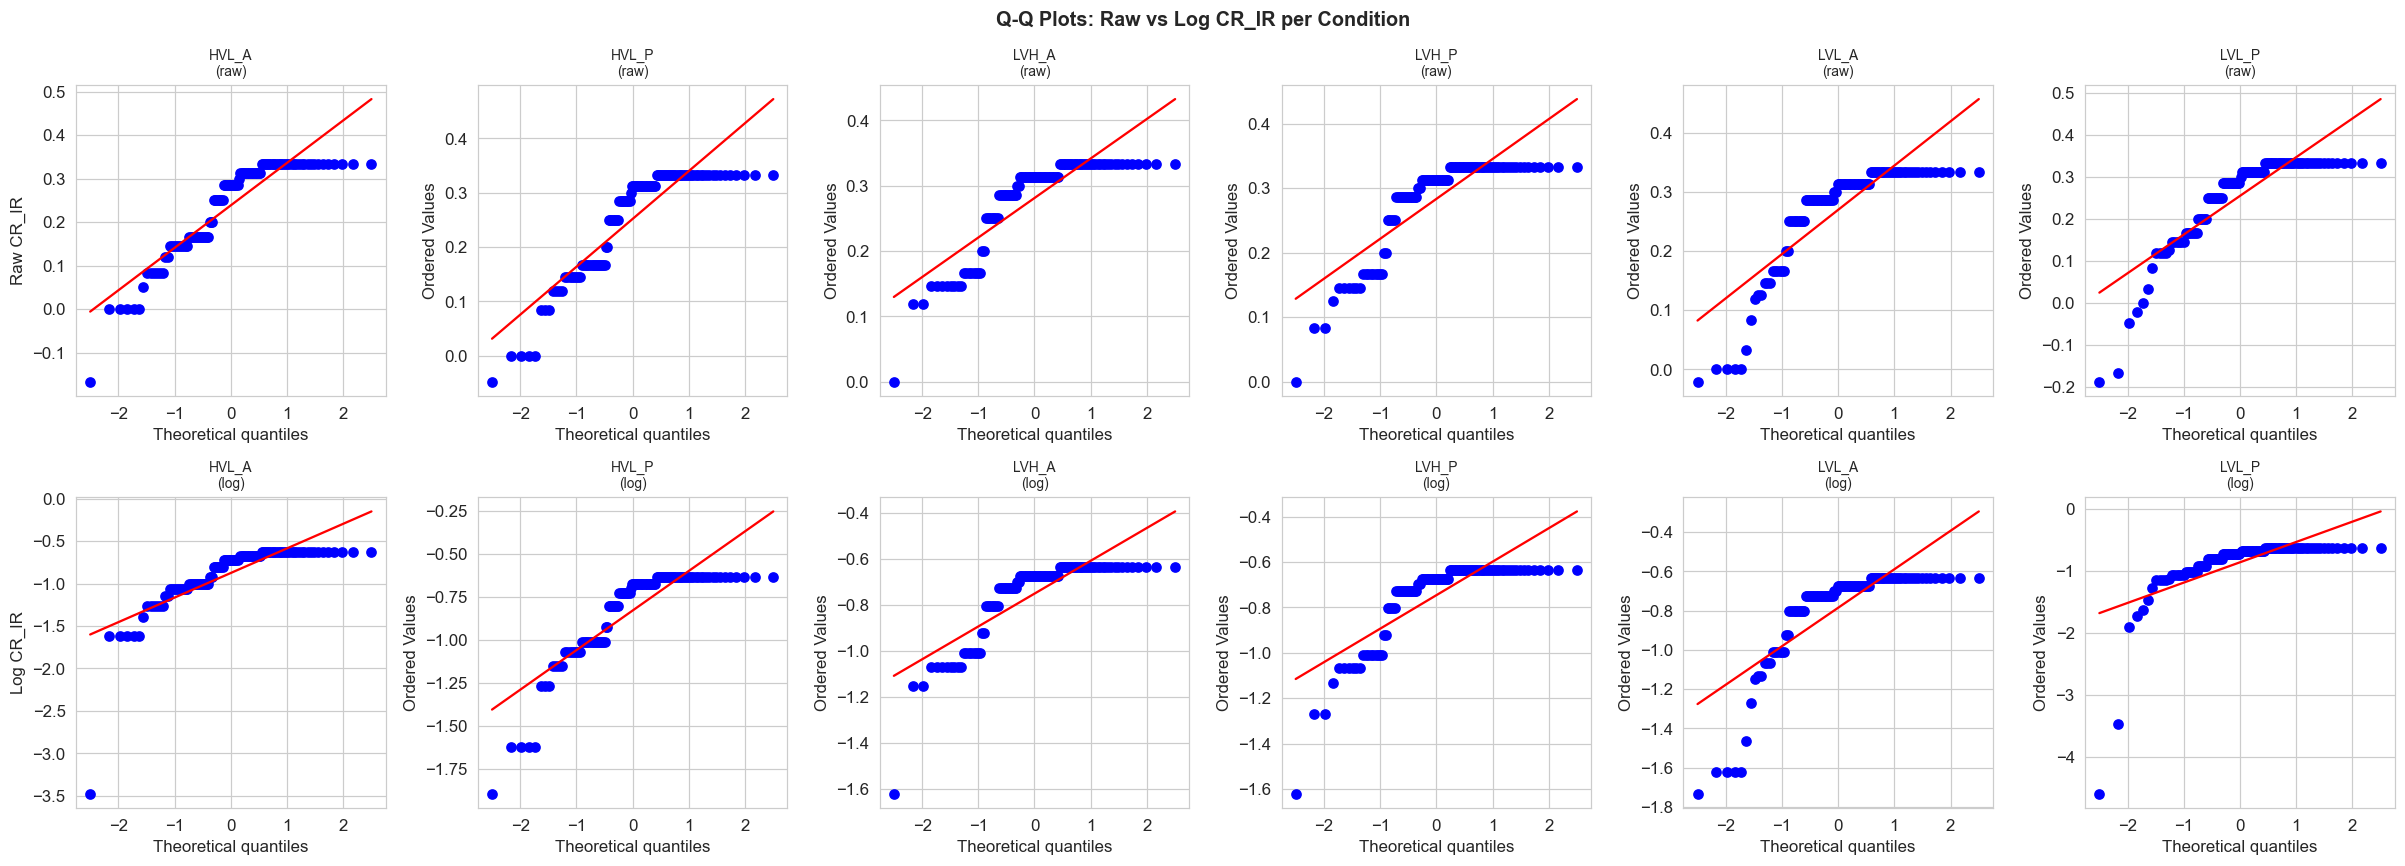

In [4]:
print('=== NORMALITY CHECK: CR_IR (raw) by condition × voice ===')
norm_raw = normality_table(cr_long, 'cr_ir', 'cond_voice', 'Shapiro-Wilk — Raw CR_IR')
print('\n=== NORMALITY CHECK: log(CR_IR) by condition × voice ===')
norm_log = normality_table(cr_long, 'log_cr_ir', 'cond_voice', 'Shapiro-Wilk — Log CR_IR')

# Decision
n_normal_raw = norm_raw['normal'].sum()
n_normal_log = norm_log['normal'].sum()
print(f'\nDecision:')
print(f'  Raw CR_IR: {n_normal_raw}/{len(norm_raw)} conditions normal')
print(f'  Log CR_IR: {n_normal_log}/{len(norm_log)} conditions normal')
if n_normal_log >= len(norm_log):
    print('  → Log transform achieves normality → USE PARAMETRIC TESTS')
    USE_PARAMETRIC = True
else:
    print('  → Log transform does NOT achieve normality → USE NON-PARAMETRIC TESTS')
    USE_PARAMETRIC = False

# Q-Q plots for both raw and log
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
for i, cv in enumerate(COND_ORDER):
    raw_data = cr_long[cr_long['cond_voice']==cv]['cr_ir'].dropna()
    log_data = cr_long[cr_long['cond_voice']==cv]['log_cr_ir'].dropna()
    stats.probplot(raw_data, plot=axes[0,i])
    axes[0,i].set_title(f'{cv}\n(raw)', fontsize=9)
    stats.probplot(log_data, plot=axes[1,i])
    axes[1,i].set_title(f'{cv}\n(log)', fontsize=9)
axes[0,0].set_ylabel('Raw CR_IR')
axes[1,0].set_ylabel('Log CR_IR')
plt.suptitle('Q-Q Plots: Raw vs Log CR_IR per Condition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## H1: Effect of Noun Memorability on CR_IR

H1 — Effect of Noun Memorability on CR_IR

Descriptive Statistics (participant-level):
             N   Mean  Median     SD     SE  CI95_lo  CI95_hi  Skewness     Min    Max
condition                                                                             
HVL        112 0.2454  0.2500 0.0761 0.0072   0.2313   0.2595   -1.0883 -0.0417 0.3333
LVH        112 0.2821  0.2991 0.0525 0.0050   0.2724   0.2918   -1.3793  0.0625 0.3333
LVL        112 0.2622  0.2887 0.0733 0.0069   0.2486   0.2758   -1.7333 -0.0521 0.3333

 Friedman Test (within-subject, 3 conditions):
  χ²(2) = 6.2249, p = 0.0445 *
  Kendall's W = 0.0278 (small≈0.1, medium≈0.3, large≈0.5)

Post-hoc Wilcoxon Signed-Rank (Bonferroni corrected, 3 comparisons):
Pair                 W          p_raw        p_bonf       sig    means
------------------------------------------------------------------------
HVL vs LVH           1195.5     0.0000       0.0001       ***    0.245 < 0.282
HVL vs LVL           2197.0     0.0612       0.1

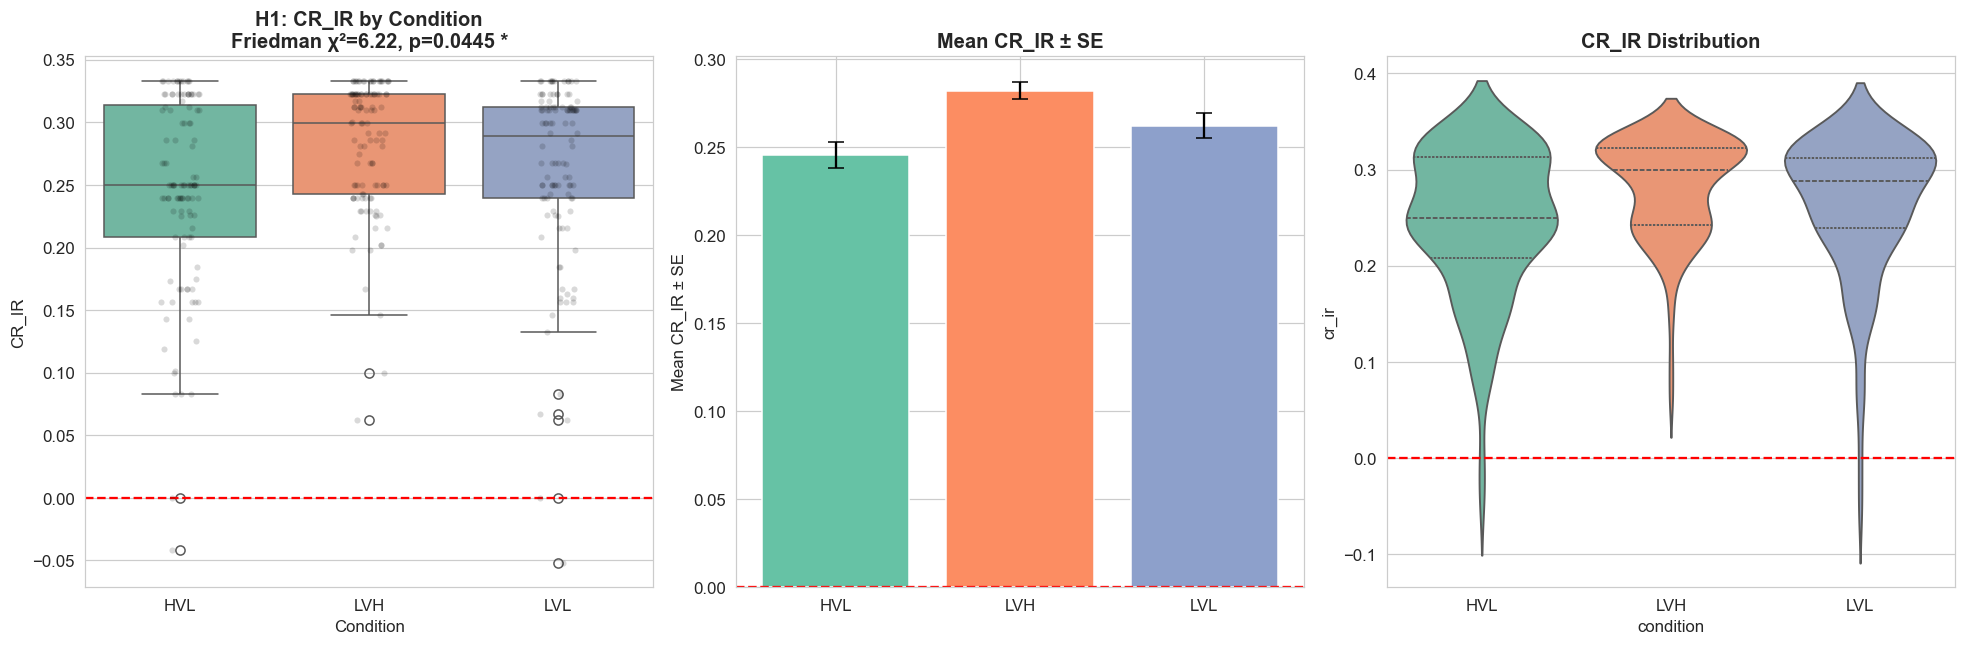

In [5]:
print('='*65)
print('H1 — Effect of Noun Memorability on CR_IR')
print('='*65)

# ── STEP 0: Aggregate per participant ─────────────────────────
df_h1 = (
    cr_long
    .groupby(['participant_ID', 'condition'])['cr_ir']
    .mean()
    .reset_index()
)

# ── Descriptive statistics ────────────────────────────────
print('\nDescriptive Statistics (participant-level):')
desc_h1 = df_h1.groupby('condition')['cr_ir'].agg(
    N='count', Mean='mean', Median='median', SD='std',
    SE=lambda x: x.sem(),
    CI95_lo=lambda x: x.mean() - 1.96*x.sem(),
    CI95_hi=lambda x: x.mean() + 1.96*x.sem(),
    Skewness='skew',
    Min='min', Max='max'
).round(4)
print(desc_h1.to_string())

# ──Friedman Test───────────────────────────────
from scipy.stats import friedmanchisquare
print('\n Friedman Test (within-subject, 3 conditions):')
pivot = df_h1.pivot(index='participant_ID', columns='condition', values='cr_ir')
pivot = pivot[TARGET_CONDITIONS].dropna()
friedman_stat, p_h1 = friedmanchisquare(
    pivot[TARGET_CONDITIONS[0]],
    pivot[TARGET_CONDITIONS[1]],
    pivot[TARGET_CONDITIONS[2]]
)
# Effect size: Kendall's W
n = pivot.shape[0]
k = len(TARGET_CONDITIONS)
kendall_w = friedman_stat / (n * (k - 1))
print(f'  χ²({k-1}) = {friedman_stat:.4f}, p = {p_h1:.4f} {sig(p_h1)}')
print(f"  Kendall's W = {kendall_w:.4f} (small≈0.1, medium≈0.3, large≈0.5)")

# ──Post-hoc Wilcoxon ─────────────────────────────
print('\nPost-hoc Wilcoxon Signed-Rank (Bonferroni corrected, 3 comparisons):')
print(f'{"Pair":<20} {"W":<10} {"p_raw":<12} {"p_bonf":<12} {"sig":<6} {"means"}')
print('-'*72)
n_comp_h1 = 3
posthoc_h1 = []
for g1, g2 in combinations(TARGET_CONDITIONS, 2):
    d1 = pivot[g1]
    d2 = pivot[g2]
    W, p = wilcoxon(d1, d2)
    p_b = min(p * n_comp_h1, 1.0)
    dirn = '>' if d1.mean() > d2.mean() else '<'
    print(f'{f"{g1} vs {g2}":<20} {W:<10.1f} {p:<12.4f} {p_b:<12.4f} {sig(p_b):<6} {d1.mean():.3f} {dirn} {d2.mean():.3f}')
    posthoc_h1.append({'g1': g1, 'g2': g2, 'W': W, 'p_raw': p, 'p_bonf': p_b})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot
sns.boxplot(data=df_h1, x='condition', y='cr_ir',
            order=TARGET_CONDITIONS, ax=axes[0], palette='Set2')
sns.stripplot(data=df_h1, x='condition', y='cr_ir',
              order=TARGET_CONDITIONS, ax=axes[0],
              color='black', alpha=0.15, size=4, jitter=True)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title(f'H1: CR_IR by Condition\nFriedman χ²={friedman_stat:.2f}, p={p_h1:.4f} {sig(p_h1)}',
                  fontweight='bold')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('CR_IR')

# Mean ± SE
means  = desc_h1['Mean']
ses    = desc_h1['SE']
colors = sns.color_palette('Set2', 3)
axes[1].bar(TARGET_CONDITIONS, means, yerr=ses, capsize=5,
            color=colors, edgecolor='white')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Mean CR_IR ± SE', fontweight='bold')
axes[1].set_ylabel('Mean CR_IR ± SE')

# Violin
sns.violinplot(data=df_h1, x='condition', y='cr_ir',
               order=TARGET_CONDITIONS, ax=axes[2],
               palette='Set2', inner='quartile')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('CR_IR Distribution', fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
from scipy.stats import levene

print('\n=== H1 Assumption Check: Levene Test ===')

lev_stat, lev_p = levene(
    df_h1[df_h1.condition=='HVL']['cr_ir'],
    df_h1[df_h1.condition=='LVH']['cr_ir'],
    df_h1[df_h1.condition=='LVL']['cr_ir']
)

print(f'Levene F = {lev_stat:.4f}, p = {lev_p:.4f} {sig(lev_p)}')

if lev_p > .05:
    print('Equal variances plausible (ANOVA assumption supported)')
else:
    print('Variance heterogeneity detected, further supporting robust nonparametric analyses.')


=== H1 Assumption Check: Levene Test ===
Levene F = 3.2689, p = 0.0393 *
Variance heterogeneity detected, further supporting robust nonparametric analyses.


## H1a: Subject vs Object Memorability Effects


Participant-level means (preview):
condition         HVL    LVH    LVL
participant_ID                     
232            0.3333 0.3229 0.3333
235            0.3095 0.2857 0.2562
236            0.3229 0.3229 0.3333
241            0.3229 0.2262 0.2396
242            0.3229 0.3229 0.1845

=== Subject Memorability Effect (High vs Low) ===
W = 1969.00, p = 0.0019 **
Means: High=0.245, Low=0.272
Effect size r = 0.378

=== Object Memorability Effect (High vs Low) ===
W = 1529.50, p = 0.0000 ***
Means: High=0.282, Low=0.254
Effect size r = 0.517


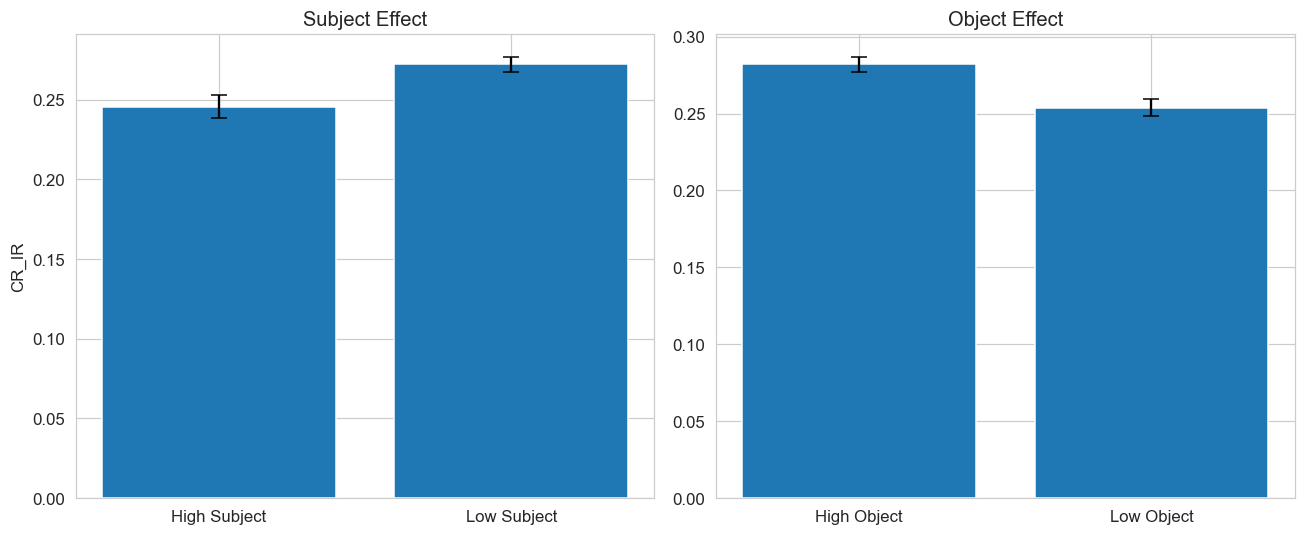

In [7]:
# ── Aggregate per participant─────────────────────────
df_h1 = (
    cr_long
    .groupby(['participant_ID','condition'])['cr_ir']
    .mean()
    .reset_index()
)

# Map condition → factors
cond_map = {'HVL': (1,0), 'LVH': (0,1), 'LVL': (0,0)}
df_h1['subject_high'] = df_h1['condition'].map(lambda c: cond_map[c][0])
df_h1['object_high']  = df_h1['condition'].map(lambda c: cond_map[c][1])

# Pivot for pairing
pivot = df_h1.pivot(index='participant_ID', columns='condition', values='cr_ir')
pivot = pivot[['HVL','LVH','LVL']].dropna()
print('\nParticipant-level means (preview):')
print(pivot.head())

# ── SUBJECT EFFECT ──────────────────────────────────────────
print('\n=== Subject Memorability Effect (High vs Low) ===')
high_subject = pivot['HVL']
low_subject  = pivot[['LVH','LVL']].mean(axis=1)
W_subj, p_subj = wilcoxon(high_subject, low_subject)
n = len(high_subject)
r_subj = 1 - (4 * W_subj) / (n * (n + 1))
print(f'W = {W_subj:.2f}, p = {p_subj:.4f} {sig(p_subj)}')
print(f'Means: High={high_subject.mean():.3f}, Low={low_subject.mean():.3f}')
print(f'Effect size r = {r_subj:.3f}')

# ── OBJECT EFFECT ───────────────────────────────────────────
print('\n=== Object Memorability Effect (High vs Low) ===')
high_object = pivot['LVH']
low_object  = pivot[['HVL','LVL']].mean(axis=1)
W_obj, p_obj = wilcoxon(high_object, low_object)
n = len(high_object)
r_obj = 1 - (4 * W_obj) / (n * (n + 1))
print(f'W = {W_obj:.2f}, p = {p_obj:.4f} {sig(p_obj)}')
print(f'Means: High={high_object.mean():.3f}, Low={low_object.mean():.3f}')
print(f'Effect size r = {r_obj:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].bar(['High Subject','Low Subject'],
          [high_subject.mean(), low_subject.mean()],
          yerr=[high_subject.sem(), low_subject.sem()],
          capsize=5)
ax[0].set_title('Subject Effect')
ax[0].set_ylabel('CR_IR')

ax[1].bar(['High Object','Low Object'],
          [high_object.mean(), low_object.mean()],
          yerr=[high_object.sem(), low_object.sem()],
          capsize=5)
ax[1].set_title('Object Effect')
plt.tight_layout()
plt.show()

## H1b: Regression: CR_IR ~ subject_high + object_high

1. Scatterplot (visual inspection)
2. Fit OLS model
3. Inspect R² and Adjusted R² (coefficient of determination)
4. F-test for overall model significance
5. t-tests for individual coefficients + confidence intervals
6. Standardized coefficients (for comparing predictors on different scales)
7. Check normality of residuals (histogram + Q-Q plot + Shapiro-Wilk)
8. Check linearity (fitted vs observed)
9. Check homogeneity of variance (Breusch-Pagan test + Scale-Location plot)
10. If heteroscedastic → apply Sandwich Estimator (HC3) and recheck coefficients
11. Cook's distance (check for influential outliers, threshold > 1)
12. VIF: check for collinearity between predictors
13. AIC model comparison (null model vs full model, Occam's razor)

=== H1b — Regression: CR_IR ~ subject_high + object_high ===
Tests additivity of noun-position memorability contributions.

Participant-level regression data:
N observations = 336
Participants = 112
Repeated observations collapsed to participant-condition means.


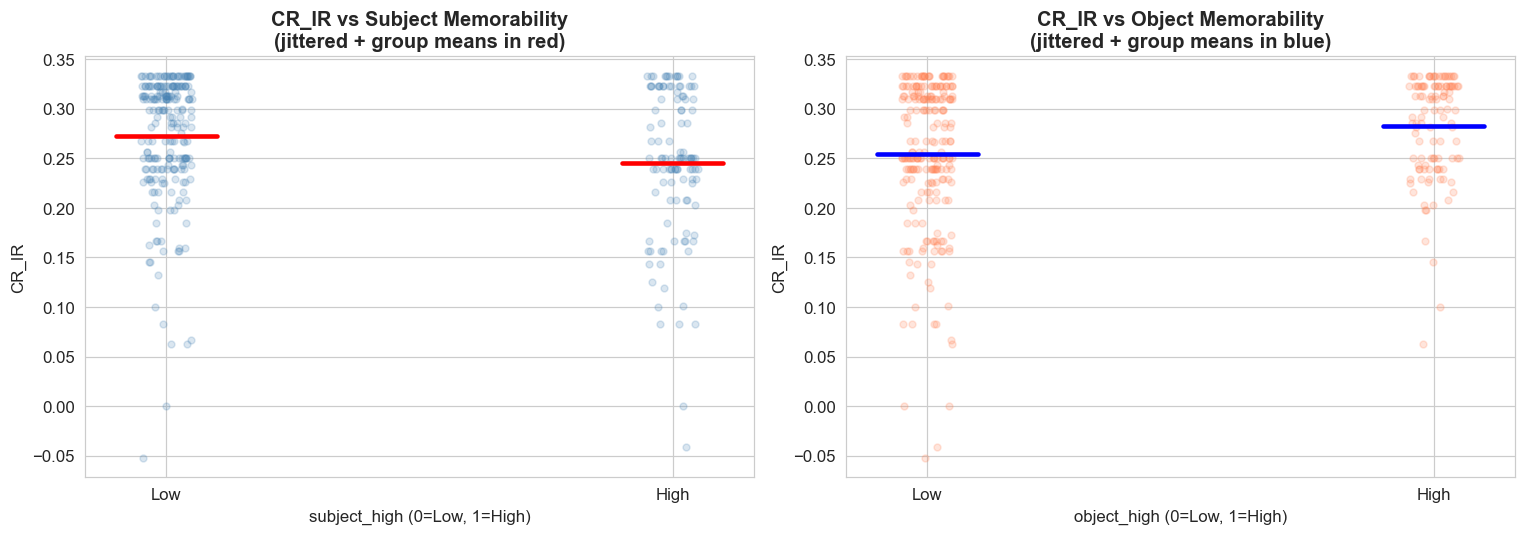

In [8]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

print('=== H1b — Regression: CR_IR ~ subject_high + object_high ===')
print('Tests additivity of noun-position memorability contributions.')

# Participant-level aggregation (fixes pseudoreplication)
# one row per participant × condition

reg_df = (
    cr_long[cr_long['condition'].isin(TARGET_CONDITIONS)]
      .groupby(['participant_ID','condition'], as_index=False)
      .agg({
          'cr_ir':'mean',
          'subject_high':'first',
          'object_high':'first'
      })
)

print('\nParticipant-level regression data:')
print(f'N observations = {len(reg_df)}')
print(f'Participants = {reg_df.participant_ID.nunique()}')
print('Repeated observations collapsed to participant-condition means.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(reg_df['subject_high'] + np.random.uniform(-0.05, 0.05, len(reg_df)),
                reg_df['cr_ir'], alpha=0.2, color='steelblue', s=20)
# Add group means
for val, label in [(0, 'Low Subject'), (1, 'High Subject')]:
    m = reg_df[reg_df['subject_high'] == val]['cr_ir'].mean()
    axes[0].plot([val-0.1, val+0.1], [m, m], 'r-', linewidth=3)
axes[0].set_xlabel('subject_high (0=Low, 1=High)')
axes[0].set_ylabel('CR_IR')
axes[0].set_title('CR_IR vs Subject Memorability\n(jittered + group means in red)', fontweight='bold')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Low','High'])

axes[1].scatter(reg_df['object_high'] + np.random.uniform(-0.05, 0.05, len(reg_df)),
                reg_df['cr_ir'], alpha=0.2, color='coral', s=20)
for val, label in [(0, 'Low Object'), (1, 'High Object')]:
    m = reg_df[reg_df['object_high'] == val]['cr_ir'].mean()
    axes[1].plot([val-0.1, val+0.1], [m, m], 'b-', linewidth=3)
axes[1].set_xlabel('object_high (0=Low, 1=High)')
axes[1].set_ylabel('CR_IR')
axes[1].set_title('CR_IR vs Object Memorability\n(jittered + group means in blue)', fontweight='bold')
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Low','High'])

plt.tight_layout()
plt.show()


In [9]:
# FIT OLS REGRESSION MODEL
model = smf.ols('cr_ir ~ subject_high + object_high', data=reg_df).fit()

# Print equation
b0  = model.params['Intercept']
b1  = model.params['subject_high']
b2  = model.params['object_high']
print(f'\nFitted equation: CR_IR = {b0:.4f} + ({b1:.4f}) × subject_high + {b2:.4f} × object_high')
print(f'  Interpretation: Intercept = baseline CR_IR when both predictors = 0 (LVL condition)')
print(f'  subject_high β = {b1:.4f}: change in CR_IR when subject memorability is High vs Low')
print(f'  object_high β  = {b2:.4f}: change in CR_IR when object memorability is High vs Low')


# R-SQUARED AND ADJUSTED R-SQUARED
# R² = 1 - SSres/SStot = proportion of variance explained
# Adjusted R² penalises for added complexity
print(f'R²          = {model.rsquared:.4f}  → {model.rsquared*100:.1f}% of variance in CR_IR explained by predictors')
print(f'Adjusted R² = {model.rsquared_adj:.4f}  → penalised for adding 2 predictors')


Fitted equation: CR_IR = 0.2622 + (-0.0168) × subject_high + 0.0199 × object_high
  Interpretation: Intercept = baseline CR_IR when both predictors = 0 (LVL condition)
  subject_high β = -0.0168: change in CR_IR when subject memorability is High vs Low
  object_high β  = 0.0199: change in CR_IR when object memorability is High vs Low
R²          = 0.0466  → 4.7% of variance in CR_IR explained by predictors
Adjusted R² = 0.0409  → penalised for adding 2 predictors


In [10]:
# F-TEST FOR OVERALL MODEL SIGNIFICANCE
# H0: all coefficients = 0 (null model Y = b0 + ε)
# H1: at least one coefficient ≠ 0

print(f'  H₀ (null model):        CR_IR = b₀ + ε  (predictors explain nothing)')
print(f'  H₁ (alternative model): CR_IR = b₀ + b₁·subject_high + b₂·object_high + ε')
print(f'\n  F-statistic = {model.fvalue:.4f}')
print(f'  df_model    = {int(model.df_model)} (K = number of predictors)')
print(f'  df_residual = {int(model.df_resid)} (N - K - 1 = {int(model.nobs)} - {int(model.df_model)} - 1)')
print(f'  p-value     = {model.f_pvalue:.6f} {sig(model.f_pvalue)}')
if model.f_pvalue < 0.05:
    print(f'  → Overall model IS significant: the predictors jointly explain CR_IR above chance.')
    print(f'  → BUT: need to check individual coefficients — some may not be significant.')
else:
    print(f'  → Overall model is NOT significant: the model is not better than a null model.')

  H₀ (null model):        CR_IR = b₀ + ε  (predictors explain nothing)
  H₁ (alternative model): CR_IR = b₀ + b₁·subject_high + b₂·object_high + ε

  F-statistic = 8.1430
  df_model    = 2 (K = number of predictors)
  df_residual = 333 (N - K - 1 = 336 - 2 - 1)
  p-value     = 0.000353 ***
  → Overall model IS significant: the predictors jointly explain CR_IR above chance.
  → BUT: need to check individual coefficients — some may not be significant.


In [11]:
#  t-TESTS FOR INDIVIDUAL COEFFICIENTS + CONFIDENCE INTERVALS
#  CI(b) = b_hat ± t_crit × SE(b_hat), df = N-K-1)

print(f'  (t = b̂ / SE(b̂), df = N - K - 1 = {int(model.df_resid)})')
print()

coef_table = pd.DataFrame({
    'Coefficient':  model.params,
    'SE':           model.bse,
    't-value':      model.tvalues,
    'p-value':      model.pvalues,
    'Sig':          [sig(p) for p in model.pvalues],
    '95% CI lower': model.conf_int()[0],
    '95% CI upper': model.conf_int()[1]
})
print(coef_table.round(4).to_string())

print(f'\n  Interpretation:')
print(f'  - Intercept    = {b0:.4f}: expected CR_IR in LVL (baseline) condition')
print(f'  - subject_high = {b1:.4f} (p={model.pvalues["subject_high"]:.4f}): '
      f'{"SIGNIFICANT" if model.pvalues["subject_high"] < 0.05 else "NOT significant"} '
      f'→ High verbal subject memorability {"lowers" if b1 < 0 else "raises"} CR_IR by {abs(b1):.4f}')
print(f'  - object_high  = {b2:.4f} (p={model.pvalues["object_high"]:.4f}): '
      f'{"SIGNIFICANT" if model.pvalues["object_high"] < 0.05 else "NOT significant"} '
      f'→ High nonverbal object memorability {"lowers" if b2 < 0 else "raises"} CR_IR by {abs(b2):.4f}')
print(f'\n  95% CI: if CI does NOT cross 0, coefficient is significant at α=0.05')
for name in ['subject_high', 'object_high']:
    lo, hi = model.conf_int().loc[name]
    crosses = 'crosses 0 → ns' if lo < 0 < hi else 'does NOT cross 0 → significant'
    print(f'  {name}: CI [{lo:.4f}, {hi:.4f}] — {crosses}')

  (t = b̂ / SE(b̂), df = N - K - 1 = 333)

              Coefficient     SE  t-value  p-value  Sig  95% CI lower  95% CI upper
Intercept          0.2622 0.0064  40.7192   0.0000  ***        0.2495        0.2748
subject_high      -0.0168 0.0091  -1.8456   0.0658   ns       -0.0347        0.0011
object_high        0.0199 0.0091   2.1853   0.0296    *        0.0020        0.0378

  Interpretation:
  - Intercept    = 0.2622: expected CR_IR in LVL (baseline) condition
  - subject_high = -0.0168 (p=0.0658): NOT significant → High verbal subject memorability lowers CR_IR by 0.0168
  - object_high  = 0.0199 (p=0.0296): SIGNIFICANT → High nonverbal object memorability raises CR_IR by 0.0199

  95% CI: if CI does NOT cross 0, coefficient is significant at α=0.05
  subject_high: CI [-0.0347, 0.0011] — crosses 0 → ns
  object_high: CI [0.0020, 0.0378] — does NOT cross 0 → significant


In [12]:
# Relative Predictor Contributions
# Better than standardized beta for dummy predictors

print('Standardized beta less ideal for binary predictors;')
print('using coefficient magnitudes and |t|-values instead.\n')

coef_compare = pd.DataFrame({
    'Predictor':['subject_high','object_high'],
    'Coefficient':[abs(b1), abs(b2)],
    '|t|':[abs(model.tvalues['subject_high']),
          abs(model.tvalues['object_high'])]
})

print(coef_compare.round(4).to_string(index=False))

stronger_coef = coef_compare.loc[
    coef_compare['Coefficient'].idxmax(),
    'Predictor'
]

print(f'\nLarger coefficient contribution: {stronger_coef}')
print('Interpretation: For dummy predictors, raw coefficients are more interpretable than standardized betas.')

Standardized beta less ideal for binary predictors;
using coefficient magnitudes and |t|-values instead.

   Predictor  Coefficient    |t|
subject_high       0.0168 1.8456
 object_high       0.0199 2.1853

Larger coefficient contribution: object_high
Interpretation: For dummy predictors, raw coefficients are more interpretable than standardized betas.


  Residual summary (check: median ≈ 0, 1Q and 3Q approx equidistant from 0):
  Min=-0.3143  1Q=-0.0330  Median=0.0076  3Q=0.0503  Max=0.0880

  Shapiro-Wilk test on residuals: W=0.8926, p=0.000000 ***
  → Residuals are NOT normally distributed (Shapiro-Wilk significant)


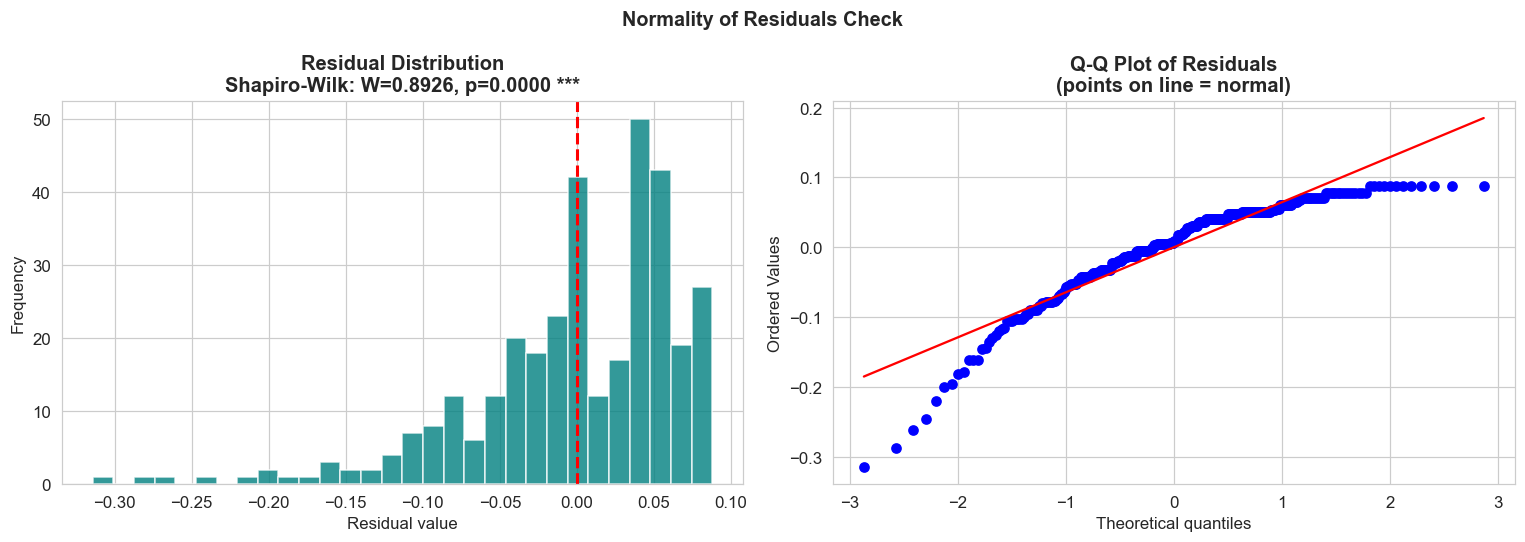

In [13]:
# NORMALITY OF RESIDUALS
# check median ≈ 0, 1Q and 3Q approx equidistant; histogram + Q-Q + Shapiro)

resid = model.resid
print(f'  Residual summary (check: median ≈ 0, 1Q and 3Q approx equidistant from 0):')
print(f'  Min={resid.min():.4f}  1Q={resid.quantile(0.25):.4f}  '
      f'Median={resid.median():.4f}  3Q={resid.quantile(0.75):.4f}  Max={resid.max():.4f}')

w_r, p_r = shapiro(resid)
print(f'\n  Shapiro-Wilk test on residuals: W={w_r:.4f}, p={p_r:.6f} {sig(p_r)}')
if p_r > 0.05:
    print('  → Residuals ARE normally distributed (Shapiro-Wilk not significant)')
else:
    print('  → Residuals are NOT normally distributed (Shapiro-Wilk significant)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(resid, bins=30, color='teal', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual value')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Residual Distribution\nShapiro-Wilk: W={w_r:.4f}, p={p_r:.4f} {sig(p_r)}',
                  fontweight='bold')

# Q-Q plot
stats.probplot(resid, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals\n(points on line = normal)', fontweight='bold')

plt.suptitle('Normality of Residuals Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

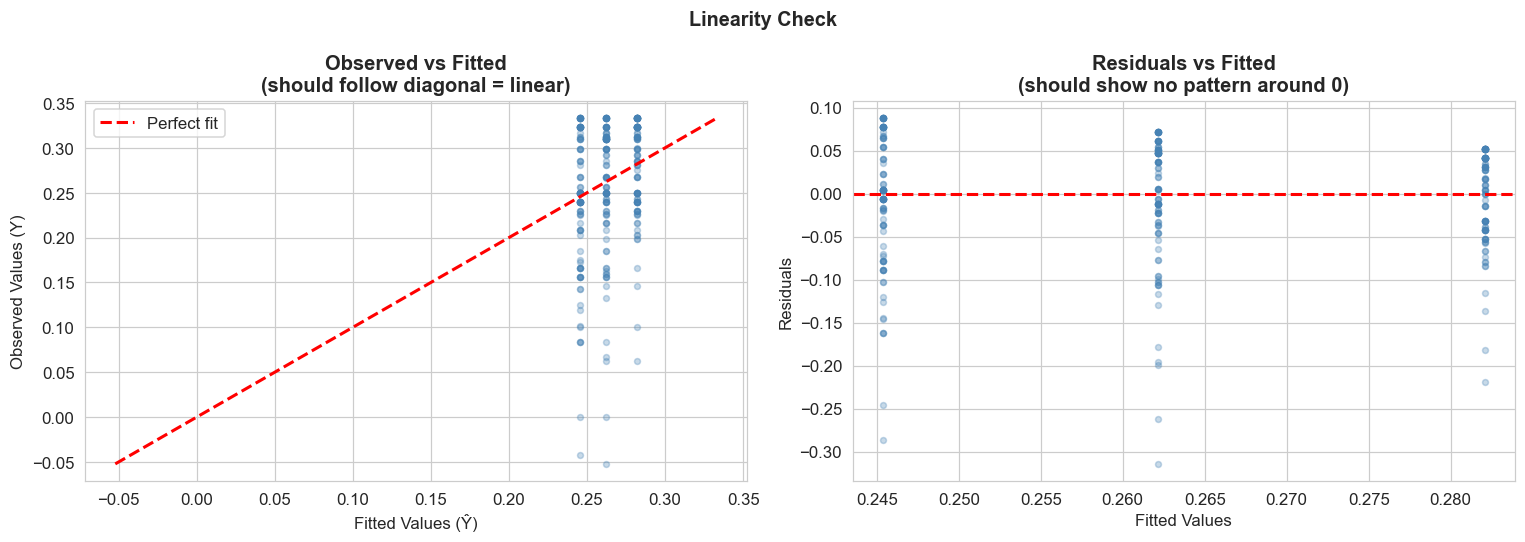

  If residuals show curved pattern → linearity assumption violated.
  If residuals show fan shape → homogeneity violated.


In [14]:
# CHECK LINEARITY
# residuals vs fitted — should show no pattern around 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observed vs Fitted 
axes[0].scatter(model.fittedvalues, reg_df['cr_ir'], alpha=0.3, color='steelblue', s=15)
min_val = min(model.fittedvalues.min(), reg_df['cr_ir'].min())
max_val = max(model.fittedvalues.max(), reg_df['cr_ir'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Fitted Values (Ŷ)')
axes[0].set_ylabel('Observed Values (Y)')
axes[0].set_title('Observed vs Fitted\n(should follow diagonal = linear)', fontweight='bold')
axes[0].legend()

# Residuals vs Fitted (check for non-linear patterns)
axes[1].scatter(model.fittedvalues, resid, alpha=0.3, color='steelblue', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted\n(should show no pattern around 0)', fontweight='bold')

plt.suptitle('Linearity Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('  If residuals show curved pattern → linearity assumption violated.')
print('  If residuals show fan shape → homogeneity violated.')


  Breusch-Pagan test: χ²=5.8968, p=0.0524 ns
  → Homoscedasticity assumed (p > 0.05) — standard SEs are valid


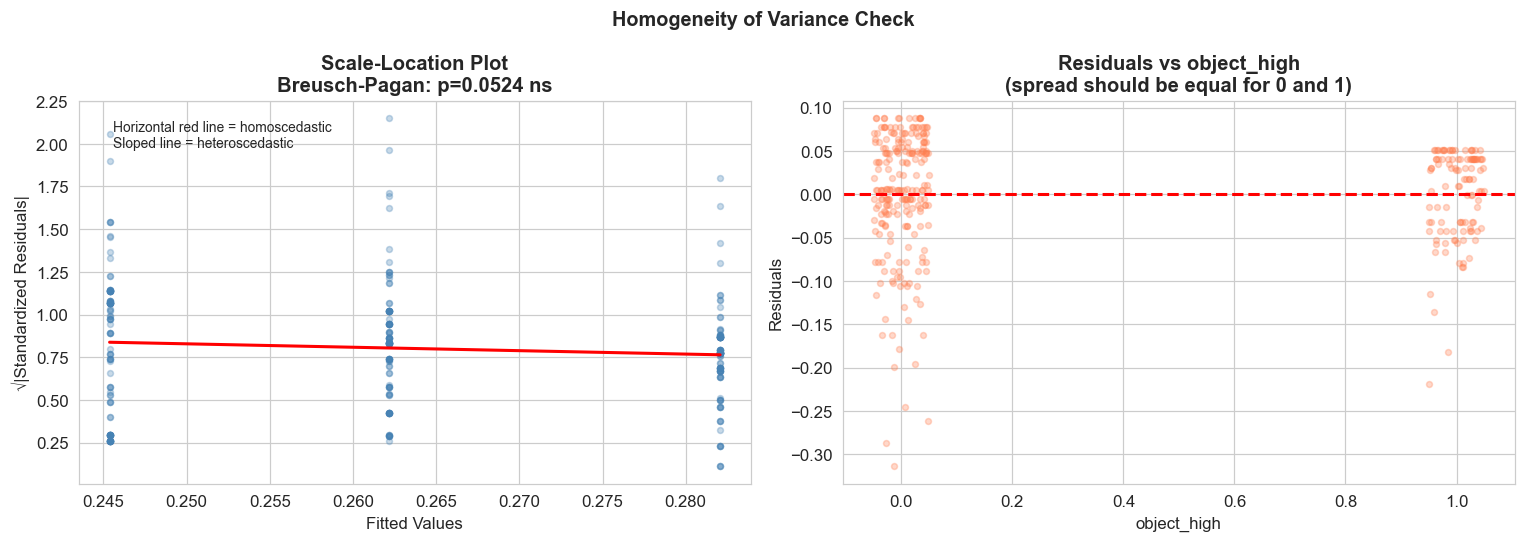

In [15]:
# CHECK HOMOGENEITY OF VARIANCE (Heteroscedasticity)
# use Breusch-Pagan test + Scale-Location plot)

bp_stat, bp_p, f_stat, f_p = het_breuschpagan(resid, model.model.exog)
print(f'\n  Breusch-Pagan test: χ²={bp_stat:.4f}, p={bp_p:.4f} {sig(bp_p)}')
if bp_p < 0.05:
    print('  → HETEROSCEDASTICITY DETECTED (p < 0.05)')
    print('  → Lecture fix: SE estimates based on homogeneity will be WRONG')
    print('  → Must apply Sandwich Estimator (HC3) — see Step 10')
else:
    print('  → Homoscedasticity assumed (p > 0.05) — standard SEs are valid')

# Scale-Location plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scale-Location plot
std_resid = np.sqrt(np.abs(resid / resid.std()))
axes[0].scatter(model.fittedvalues, std_resid, alpha=0.3, color='steelblue', s=15)
# Add smoothed line
from scipy.stats import pearsonr
z = np.polyfit(model.fittedvalues, std_resid, 1)
p_fit = np.poly1d(z)
x_sorted = np.sort(model.fittedvalues)
axes[0].plot(x_sorted, p_fit(x_sorted), 'r-', linewidth=2)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('√|Standardized Residuals|')
axes[0].set_title(f'Scale-Location Plot\nBreusch-Pagan: p={bp_p:.4f} {sig(bp_p)}', fontweight='bold')
axes[0].text(0.05, 0.95, 'Horizontal red line = homoscedastic\nSloped line = heteroscedastic',
             transform=axes[0].transAxes, fontsize=9, va='top')

# Residuals vs each predictor
axes[1].scatter(reg_df['object_high'] + np.random.uniform(-0.05,0.05,len(reg_df)),
                resid, alpha=0.3, color='coral', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('object_high')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs object_high\n(spread should be equal for 0 and 1)', fontweight='bold')

plt.suptitle('Homogeneity of Variance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
if bp_p < 0.05:
    print('  Heteroscedasticity detected → Applying HC3 Sandwich Estimator')
    print('  (lecture: use heteroscedasticity-corrected covariance matrix)')
    robust_model = model.get_robustcov_results(cov_type='HC3')

    # Extract confidence intervals properly
    conf_int = robust_model.conf_int()
    
    robust_table = pd.DataFrame({
        'Coefficient':     robust_model.params,
        'SE (HC3)':        robust_model.bse,
        't-value':         robust_model.tvalues,
        'p-value (HC3)':   robust_model.pvalues,
        'Sig':             [sig(p) for p in robust_model.pvalues],
        '95% CI lower':    conf_int[:, 0],
        '95% CI upper':    conf_int[:, 1]
    })
    print('\n  HC3 Robust Coefficient Table:')
    print(robust_table.round(4).to_string())

    print('\n  Comparison — Standard SE vs HC3 Robust SE:')
    param_names = model.params.index.tolist()  # Use original model's index
    for i, name in enumerate(param_names):
        if name in ['subject_high', 'object_high']:
            std_se    = model.bse[name]
            robust_se = robust_model.bse[i]
            std_p     = model.pvalues[name]
            rob_p     = robust_model.pvalues[i]
            print(f'  {name}: SE {std_se:.4f}→{robust_se:.4f}, p {std_p:.4f}→{rob_p:.4f} '
                  f'({sig(std_p)}→{sig(rob_p)})')

    print('\n  → USE HC3 results for final inference (corrects for unequal variance)')
    final_model = robust_model
else:
    print('  Homoscedasticity assumed → Sandwich estimator NOT needed.')
    print('  Standard OLS SEs are valid.')
    final_model = model

  Homoscedasticity assumed → Sandwich estimator NOT needed.
  Standard OLS SEs are valid.



  Max Cook's D  = 0.0644
  Mean Cook's D = 0.0030
  N with D > 1  = 0 (threshold from lecture)
  → No influential outliers (all Cook's D < 1). Results are stable.


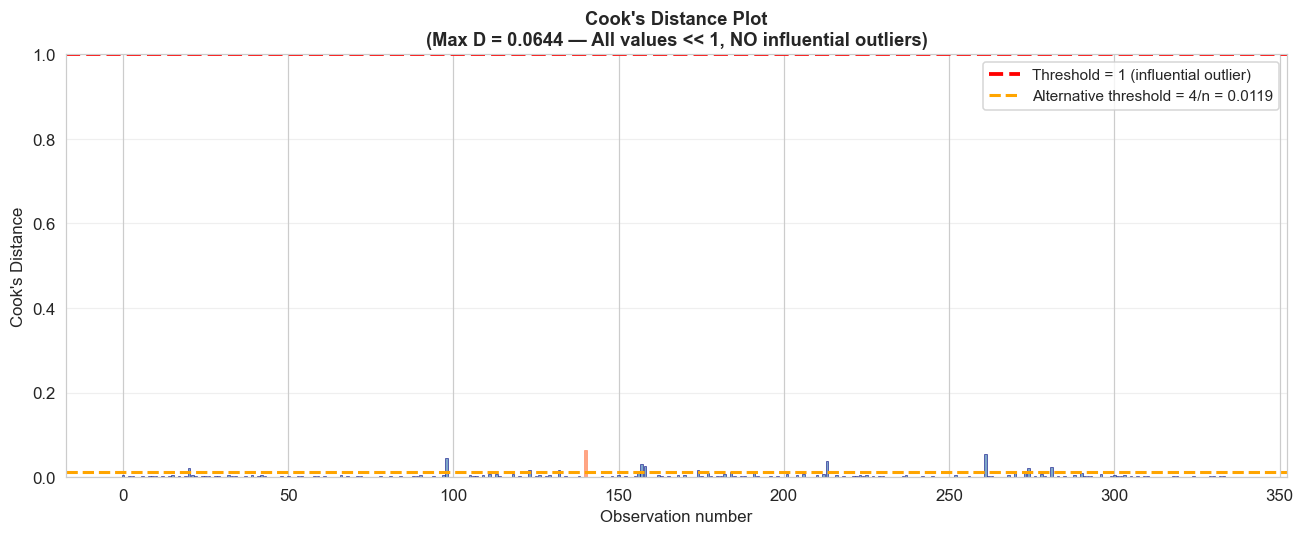

All Cook's D values well below threshold (max=0.0644 << 1)
No influential outliers detected — regression results are stable


In [17]:
# COOK'S DISTANCE — OUTLIER INFLUENCE CHECK
# remove and re-run to check if results change substantially)

infl   = model.get_influence()
cooks  = infl.cooks_distance[0]
n_influential = (cooks > 1).sum()

print(f'\n  Max Cook\'s D  = {cooks.max():.4f}')
print(f'  Mean Cook\'s D = {cooks.mean():.4f}')
print(f'  N with D > 1  = {n_influential} (threshold from lecture)')

if cooks.max() > 1:
    print('  → Influential outlier(s) detected!')
    print('  → Re-running without most influential point to check stability...')
    worst_idx = np.argmax(cooks)
    reg_df_clean = reg_df.drop(reg_df.index[worst_idx])
    model_clean  = smf.ols('cr_ir ~ subject_high + object_high', data=reg_df_clean).fit()
    print(f'  Original:  subject_high={b1:.4f}, object_high={b2:.4f}')
    print(f'  Without outlier: subject_high={model_clean.params["subject_high"]:.4f}, '
          f'object_high={model_clean.params["object_high"]:.4f}')
    print('  → If coefficients change substantially, outlier had large influence.')
else:
    print('  → No influential outliers (all Cook\'s D < 1). Results are stable.')

# Cook's distance plot 
fig, ax = plt.subplots(figsize=(12, 5))

# Plot bars
bars = ax.bar(range(len(cooks)), cooks, color='steelblue', alpha=0.7, edgecolor='navy', linewidth=0.5)

# Add thresholds
ax.axhline(1.0, color='red', linestyle='--', linewidth=2.5, label="Threshold = 1 (influential outlier)")
ax.axhline(4/len(cooks), color='orange', linestyle='--', linewidth=2, 
           label=f'Alternative threshold = 4/n = {4/len(cooks):.4f}')

# Highlight max value
max_idx = np.argmax(cooks)
bars[max_idx].set_color('coral')

ax.set_xlabel('Observation number', fontsize=11)
ax.set_ylabel("Cook's Distance", fontsize=11)
ax.set_title(f"Cook's Distance Plot\n(Max D = {cooks.max():.4f} — All values << 1, NO influential outliers)",
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim([0, max(1.0, cooks.max() * 1.5)])  # Give some space above max value

# Add grid for readability
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'All Cook\'s D values well below threshold (max={cooks.max():.4f} << 1)')
print(f'No influential outliers detected — regression results are stable')

In [18]:
# COLLINEARITY CHECK — VIF
# VIF_k = 1/(1-R²_{-k}); rule of thumb: VIF > 5 or 10 is problematic)

# Build design matrix for VIF
X_vif = reg_df[['subject_high', 'object_high']].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Variable'] = ['subject_high', 'object_high']
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, 1),
    variance_inflation_factor(X_vif.values, 2)
]

print(f'{vif_data.to_string(index=False)}')
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        status = 'SEVERE collinearity'
    elif row['VIF'] > 5:
        status = 'MODERATE collinearity — consider removing or combining'
    else:
        status = 'acceptable (< 5)'
    print(f'  {row["Variable"]}: VIF={row["VIF"]:.4f} → {status}')

# Also report correlation between predictors
r_pred = reg_df[['subject_high','object_high']].corr().iloc[0,1]
print(f'\n  Pearson correlation between predictors: r = {r_pred:.4f}')

    Variable    VIF
subject_high 1.3333
 object_high 1.3333
  subject_high: VIF=1.3333 → acceptable (< 5)
  object_high: VIF=1.3333 → acceptable (< 5)

  Pearson correlation between predictors: r = -0.5000


In [19]:
# AIC MODEL COMPARISON (Occam's Razor)
# compare full model vs null model and vs subject-only / object-only models)

# Fit competing models
model_null    = smf.ols('cr_ir ~ 1',            data=reg_df).fit()  # intercept only
model_subj    = smf.ols('cr_ir ~ subject_high', data=reg_df).fit()  # subject only
model_obj     = smf.ols('cr_ir ~ object_high',  data=reg_df).fit()  # object only
model_full    = model  # subject + object (already fitted)

aic_table = pd.DataFrame({
    'Model':      ['Null (intercept only)', 'subject_high only', 'object_high only',
                   'subject_high + object_high (full)'],
    'K':          [1, 2, 2, 3],
    'R²':         [0, model_subj.rsquared, model_obj.rsquared, model_full.rsquared],
    'Adj. R²':    [0, model_subj.rsquared_adj, model_obj.rsquared_adj, model_full.rsquared_adj],
    'AIC':        [model_null.aic, model_subj.aic, model_obj.aic, model_full.aic],
    'BIC':        [model_null.bic, model_subj.bic, model_obj.bic, model_full.bic],
})
aic_table = aic_table.round(4)
print(f'\n{aic_table.to_string(index=False)}')

best_model = aic_table.loc[aic_table['AIC'].idxmin(), 'Model']
print(f'\n  Best model by AIC: "{best_model}"')
print(f'  Note: Δ AIC > 2 = meaningful difference; Δ AIC > 10 = strong evidence')

delta_aic = aic_table['AIC'].values - aic_table['AIC'].min()
for i, (mod, daic) in enumerate(zip(aic_table['Model'], delta_aic)):
    strength = 'best' if daic == 0 else ('substantial' if daic > 10 else ('moderate' if daic > 2 else 'similar'))
    print(f'  ΔAIC={daic:.2f} → {mod}: {strength}')


                            Model  K     R²  Adj. R²       AIC       BIC
            Null (intercept only)  1 0.0000   0.0000 -836.5695 -832.7523
                subject_high only  2 0.0330   0.0301 -845.8289 -838.1947
                 object_high only  2 0.0369   0.0340 -847.1937 -839.5595
subject_high + object_high (full)  3 0.0466   0.0409 -848.6131 -837.1617

  Best model by AIC: "subject_high + object_high (full)"
  Note: Δ AIC > 2 = meaningful difference; Δ AIC > 10 = strong evidence
  ΔAIC=12.04 → Null (intercept only): substantial
  ΔAIC=2.78 → subject_high only: moderate
  ΔAIC=1.42 → object_high only: similar
  ΔAIC=0.00 → subject_high + object_high (full): best


## H2: Effect of Voice (Active vs Passive) on CR_IR

H2 — Voice Effect (Active vs Passive) on CR_IR

Descriptive Statistics:
         N   Mean  Median     SD     SE
voice                                  
A      336 0.2631  0.3125 0.0900 0.0049
P      336 0.2633  0.3125 0.0931 0.0051

Difference (Active − Passive) per participant:
  Mean diff = -0.0002
  SD diff   = 0.0688

Shapiro-Wilk on differences: W=0.9926, p=0.8123 → Normal

Paired t-test (differences normal): t=-0.0368, p=0.9707 ns, Cohen's d=-0.003

--- Voice effect within each memorability condition (Wilcoxon + Bonferroni, 3 tests) ---
Condition  W          p_raw        p_bonf       sig    Active mean    Passive mean
----------------------------------------------------------------------
HVL        1647.5     0.3359       1.0000       ns     0.2388         0.2520
LVH        1540.0     0.8445       1.0000       ns     0.2810         0.2831
LVL        1599.0     0.3162       0.9486       ns     0.2695         0.2549


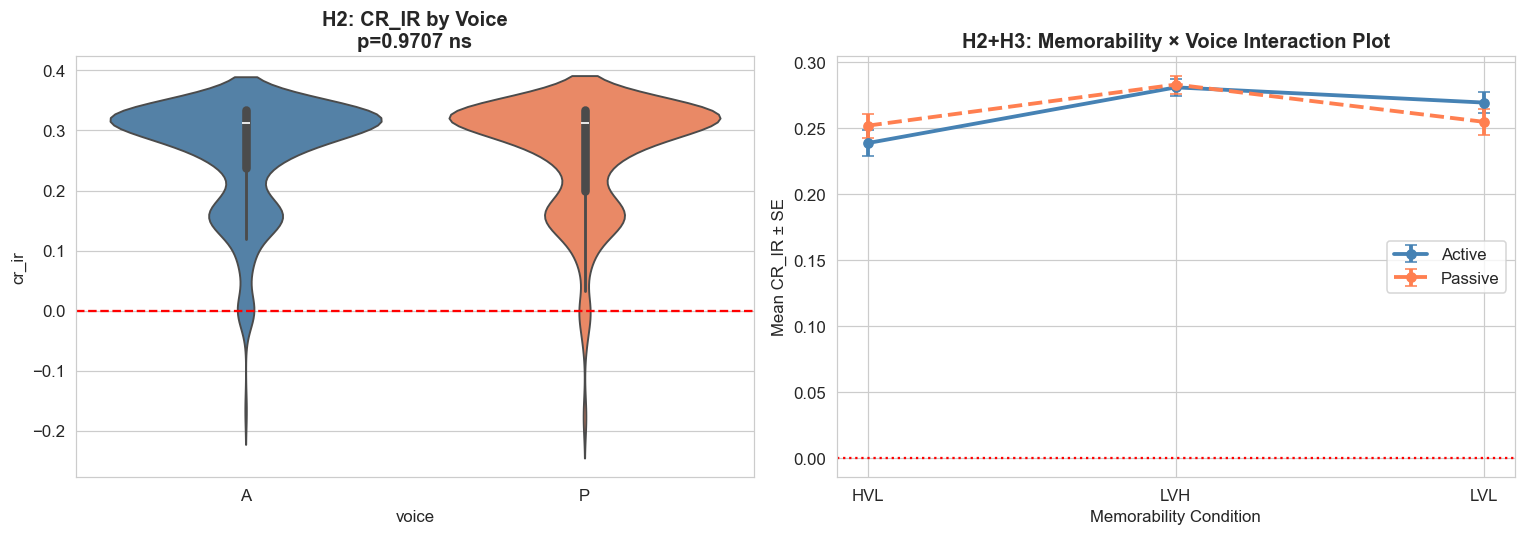

In [20]:
print('='*65)
print('H2 — Voice Effect (Active vs Passive) on CR_IR')
print('='*65)

# Descriptive
print('\nDescriptive Statistics:')
desc_h2 = cr_long.groupby('voice')['cr_ir'].agg(
    N='count', Mean='mean', Median='median', SD='std',
    SE=lambda x: x.sem()).round(4)
print(desc_h2.to_string())

# Difference scores (A-P) per participant
pivot_v = cr_long.pivot_table(index='participant_ID', columns='voice', values='cr_ir')
pivot_v['diff_A_minus_P'] = pivot_v['A'] - pivot_v['P']
print(f'\nDifference (Active − Passive) per participant:')
print(f'  Mean diff = {pivot_v["diff_A_minus_P"].mean():.4f}')
print(f'  SD diff   = {pivot_v["diff_A_minus_P"].std():.4f}')

# Normality of differences
w_d, p_d = shapiro(pivot_v['diff_A_minus_P'].dropna())
print(f'\nShapiro-Wilk on differences: W={w_d:.4f}, p={p_d:.4f} → {"Normal" if p_d > 0.05 else "Non-normal"}')

# Test
d_A = pivot_v['A'].dropna()
d_P = pivot_v['P'].dropna()
common = d_A.index.intersection(d_P.index)
if p_d > 0.05:
    from scipy.stats import ttest_rel
    t_h2, p_h2 = ttest_rel(d_A[common], d_P[common])
    d_es = cohens_d_paired(d_A[common], d_P[common])
    print(f"\nPaired t-test (differences normal): t={t_h2:.4f}, p={p_h2:.4f} {sig(p_h2)}, Cohen's d={d_es:.3f}")
else:
    W_h2, p_h2 = wilcoxon(d_A[common], d_P[common])
    r_h2 = wilcoxon_r(W_h2, len(common))
    print(f'\nWilcoxon Signed-Rank (differences non-normal): W={W_h2:.1f}, p={p_h2:.4f} {sig(p_h2)}, r={r_h2:.3f}')

# Within each condition
print('\n--- Voice effect within each memorability condition (Wilcoxon + Bonferroni, 3 tests) ---')
print(f'{"Condition":<10} {"W":<10} {"p_raw":<12} {"p_bonf":<12} {"sig":<6} {"Active mean":<14} {"Passive mean"}')
print('-'*70)
for cond in TARGET_CONDITIONS:
    sub = cr_long[cr_long['condition']==cond]
    act = sub[sub['voice']=='A'].set_index('participant_ID')['cr_ir']
    pas = sub[sub['voice']=='P'].set_index('participant_ID')['cr_ir']
    m   = pd.concat([act,pas],axis=1,keys=['A','P']).dropna()
    W_c, p_c = wilcoxon(m['A'], m['P'])
    p_b = min(p_c * 3, 1.0)
    print(f'{cond:<10} {W_c:<10.1f} {p_c:<12.4f} {p_b:<12.4f} {sig(p_b):<6} {m["A"].mean():<14.4f} {m["P"].mean():.4f}')

# Plot
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.violinplot(data=cr_long, x='voice', y='cr_ir', ax=axes[0], palette=['steelblue','coral'])
axes[0].axhline(0,color='red',linestyle='--')
axes[0].set_title(f'H2: CR_IR by Voice\np={p_h2:.4f} {sig(p_h2)}',fontweight='bold')

interaction = cr_long.groupby(['condition','voice'])['cr_ir'].agg(mean='mean',sem=lambda x:x.sem()).reset_index()
for v, ls, col in [('A','-','steelblue'),('P','--','coral')]:
    sub = interaction[interaction['voice']==v]
    axes[1].errorbar(sub['condition'],sub['mean'],yerr=sub['sem'],linestyle=ls,marker='o',
                     capsize=4,linewidth=2.5,color=col,label=f'{"Active" if v=="A" else "Passive"}')
axes[1].axhline(0,color='red',linestyle=':'); axes[1].legend()
axes[1].set_title('H2+H3: Memorability × Voice Interaction Plot',fontweight='bold')
axes[1].set_xlabel('Memorability Condition'); axes[1].set_ylabel('Mean CR_IR ± SE')
plt.tight_layout(); plt.show()

## H3: Memorability × Voice Interaction 

In [21]:
# Define h3_df 
h3_df = cr_long[cr_long['condition'].isin(TARGET_CONDITIONS)].copy()

for cond in TARGET_CONDITIONS:
    for voice in sorted(h3_df.voice.unique()):
        vals = h3_df[
            (h3_df.condition==cond)&
            (h3_df.voice==voice)
        ]['cr_ir']
        
        W,p = shapiro(vals)
        print(
            f'{cond}-{voice}: '
            f'W={W:.4f}, p={p:.4f} {sig(p)}'
        )

HVL-A: W=0.8320, p=0.0000 ***
HVL-P: W=0.8039, p=0.0000 ***
LVH-A: W=0.7377, p=0.0000 ***
LVH-P: W=0.7176, p=0.0000 ***
LVL-A: W=0.7193, p=0.0000 ***
LVL-P: W=0.7513, p=0.0000 ***


In [22]:
print('=== H3 — Memorability × Voice Interaction on CR_IR ===')
import pingouin as pg

h3_df = cr_long[cr_long['condition'].isin(TARGET_CONDITIONS)].copy()

print('\n--- Repeated Measures ANOVA: condition × voice ---')
aov2 = pg.rm_anova(
    dv='cr_ir',
    within=['condition', 'voice'],
    subject='participant_ID',
    data=h3_df,
    detailed=True
)
print(aov2[['Source','ddof1','ddof2','F','p_unc','p_GG_corr','ng2','eps']].to_string())

row_inter  = aov2[aov2['Source'] == 'condition * voice'].iloc[0]
F_inter    = row_inter['F']
p_inter    = row_inter['p_GG_corr']
eta_inter  = row_inter['ng2']
print(f'\nInteraction Effect (Condition × Voice):')
print(f'  F = {F_inter:.4f}, p = {p_inter:.4f} {sig(p_inter)}, η² = {eta_inter:.4f}')

print('\n--- Sphericity (Mauchly\'s test for condition) ---')
sph  = pg.sphericity(dv='cr_ir', within='condition', subject='participant_ID', data=h3_df)
print(sph)
W    = sph.W
pval = sph.pval
print(f'Mauchly W = {W:.4f}, p = {pval:.4f}')
if pval < 0.05:
    print('→ Sphericity violated → use p_GG_corr')
else:
    print('→ Sphericity assumed')

=== H3 — Memorability × Voice Interaction on CR_IR ===

--- Repeated Measures ANOVA: condition × voice ---
              Source  ddof1  ddof2       F  p_unc  p_GG_corr    ng2    eps
0          condition      2    222 10.4764 0.0000     0.0001 0.0270 0.9218
1              voice      1    111  0.0014 0.9707     0.9707 0.0000 1.0000
2  condition * voice      2    222  1.5594 0.2126     0.2138 0.0040 0.9426

Interaction Effect (Condition × Voice):
  F = 1.5594, p = 0.2138 ns, η² = 0.0040

--- Sphericity (Mauchly's test for condition) ---
SpherResults(spher=False, W=np.float64(0.9152072660956633), chi2=np.float64(9.746519093887528), dof=2, pval=np.float64(0.0076483943126649185))
Mauchly W = 0.9152, p = 0.0076
→ Sphericity violated → use p_GG_corr


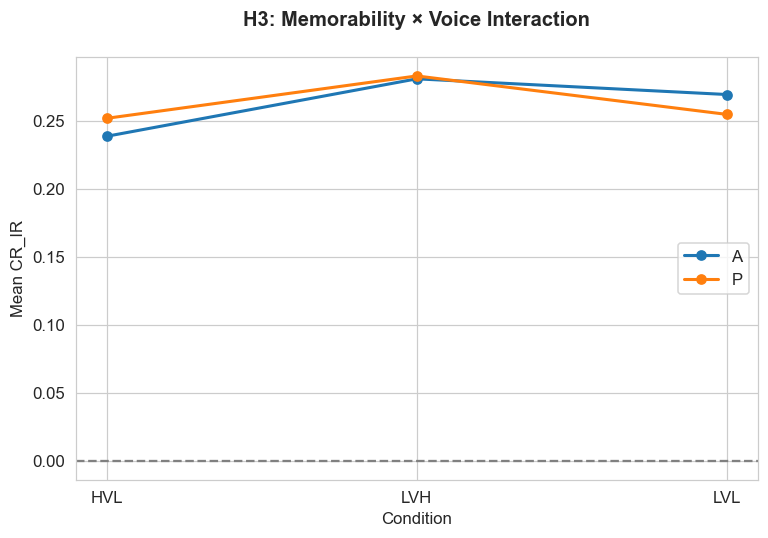

In [23]:
# ======================================================
# H3 Interaction Plot
# ======================================================
means = (
    h3_df
    .groupby(['condition','voice'])['cr_ir']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

for v in means['voice'].unique():
    sub = means[means.voice==v]
    plt.plot(
        sub['condition'],
        sub['cr_ir'],
        marker='o',
        linewidth=2,
        label=v
    )
    
plt.axhline(0, color='gray', linestyle='--')
plt.title('H3: Memorability × Voice Interaction\n', fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Mean CR_IR')
plt.legend()

plt.show()

## H4: Effect of Memorability on WR Hit Rate

In [24]:
print('=== H4 — Effect of Memorability on WR Hit Rate ===')

print('\nDescriptive:')
desc_wr = cr_long.groupby('cond_voice')['hit_rate_wr'].agg(
    N='count', Mean='mean', Median='median', SD='std',
    SE=lambda x: x.sem()
).round(4)
print(desc_wr.to_string())

norm_wr = normality_table(cr_long, 'hit_rate_wr', 'cond_voice', 'Shapiro-Wilk WR Hit Rate')

print('\n--- One-sample test vs chance (0.5) ---')
print(f'{"Condition":<12} {"Mean":<8} {"t/W":<10} {"p":<12} {"sig"}')
for cv in COND_ORDER:
    data = cr_long[cr_long['cond_voice']==cv]['hit_rate_wr'].dropna()
    w_n, p_n = shapiro(data)
    if p_n > 0.05:
        t, p = ttest_1samp(data, 0.5)
        stat_lbl = f't={t:.2f}'
    else:
        try:
            W, p = wilcoxon(data - 0.5)
            stat_lbl = f'W={W:.0f}'
        except:
            t, p = ttest_1samp(data, 0.5)
            stat_lbl = f't={t:.2f}'
    print(f'{cv:<12} {data.mean():<8.3f} {stat_lbl:<10} {p:<12.4f} {sig(p)}')

print('\n--- Friedman Test: WR hit rate across 3 conditions ---')
df_wr = (
    cr_long
    .groupby(['participant_ID','condition'])['hit_rate_wr']
    .mean()
    .reset_index()
)
pivot_wr = df_wr.pivot(index='participant_ID', columns='condition', values='hit_rate_wr')
pivot_wr = pivot_wr[TARGET_CONDITIONS].dropna()
H_wr, p_wr = friedmanchisquare(
    pivot_wr[TARGET_CONDITIONS[0]],
    pivot_wr[TARGET_CONDITIONS[1]],
    pivot_wr[TARGET_CONDITIONS[2]]
)
print(f'Friedman χ²(2) = {H_wr:.4f}, p = {p_wr:.4f} {sig(p_wr)}')

if p_wr < 0.05:
    print('\nPost-hoc Wilcoxon (Bonferroni, 3 tests):')
    for g1, g2 in combinations(TARGET_CONDITIONS, 2):
        d1 = pivot_wr[g1]; d2 = pivot_wr[g2]
        W, p = wilcoxon(d1, d2)
        p_b = min(p * 3, 1.0)
        print(f'  {g1} vs {g2}: W={W:.1f}, p_raw={p:.4f}, p_bonf={p_b:.4f} {sig(p_b)}')

df_ind = (
    cr_long
    .groupby('participant_ID')[['cr_ir','hit_rate_wr']]
    .mean()
    .dropna()
)
r_ind, p_ind = spearmanr(df_ind['cr_ir'], df_ind['hit_rate_wr'])
print(f'\nH4b Independence (CR_IR vs WR): Spearman r={r_ind:.4f}, p={p_ind:.4f} {sig(p_ind)}')
print('  (Very small r → practically independent, consistent with Begg 1971)')

=== H4 — Effect of Memorability on WR Hit Rate ===

Descriptive:
              N   Mean  Median     SD     SE
cond_voice                                  
HVL_A       112 0.7751  0.8167 0.2076 0.0196
HVL_P       111 0.7197  0.7500 0.2107 0.0200
LVH_A       111 0.7685  0.8000 0.1942 0.0184
LVH_P       111 0.7547  0.8000 0.2112 0.0200
LVL_A       110 0.7436  0.7500 0.2084 0.0199
LVL_P       112 0.7173  0.7500 0.2320 0.0219

=== Shapiro-Wilk WR Hit Rate ===
Group           N      W          p-value        Normal?
-------------------------------------------------------
HVL_A           112    0.8667     1.31e-08       NO
HVL_P           111    0.9199     5.14e-06       NO
LVH_A           111    0.8965     3.14e-07       NO
LVH_P           111    0.8904     1.61e-07       NO
LVL_A           110    0.9158     3.36e-06       NO
LVL_P           112    0.9128     1.93e-06       NO

Normal groups: 0 / 6

--- One-sample test vs chance (0.5) ---
Condition    Mean     t/W        p            sig
HVL

In [25]:
print('\n=== H4a — Voice Effect on WR Hit Rate (Active vs Passive) ===')

# ── Step 1: Aggregate per participant × voice ─────────────────────────
df_voice = (
    cr_long
    .groupby(['participant_ID','voice'])['hit_rate_wr']
    .mean()
    .reset_index()
)

# Pivot to get paired data
pivot_voice = df_voice.pivot(index='participant_ID', columns='voice', values='hit_rate_wr')
pivot_voice = pivot_voice.dropna()

active  = pivot_voice['A']
passive = pivot_voice['P']

print(f'\nMeans:')
print(f'  Active  = {active.mean():.4f}')
print(f'  Passive = {passive.mean():.4f}')

# ── Step 2: Wilcoxon signed-rank test ─────────────────────────
W, p = wilcoxon(active, passive)

# ── Step 3: Effect size (rank-biserial correlation) ───────────
n = len(active)
r = 1 - (4 * W) / (n * (n + 1))

print(f'\nWilcoxon signed-rank test:')
print(f'  W = {W:.1f}, p = {p:.4f} {sig(p)}')
print(f'  Effect size r = {r:.3f}')

# ── Step 4: Direction ─────────────────────────────────────────
if active.mean() > passive.mean():
    print('  Direction: Active > Passive')
else:
    print('  Direction: Passive > Active')


=== H4a — Voice Effect on WR Hit Rate (Active vs Passive) ===

Means:
  Active  = 0.7609
  Passive = 0.7299

Wilcoxon signed-rank test:
  W = 2108.5, p = 0.0438 *
  Effect size r = 0.334
  Direction: Active > Passive


## H6: Block × Condition Fatigue Effect

Block × Condition Hit Rate Table:
                  Mean     SE    N
block condition                   
1     HVL       0.3167 0.0027  108
      LVH       0.3043 0.0055  108
      LVL       0.3022 0.0041  108
2     HVL       0.3070 0.0047  109
      LVH       0.3058 0.0048  109
      LVL       0.2937 0.0067  109
3     HVL       0.3000 0.0052  112
      LVH       0.3064 0.0040  112
      LVL       0.2917 0.0058  112

=== Shapiro-Wilk Block Hit Rate ===
Group           N      W          p-value        Normal?
-------------------------------------------------------
HVL             329    0.5856     2.74e-27       NO
LVH             329    0.5856     2.74e-27       NO
LVL             329    0.6333     5.99e-26       NO

Normal groups: 0 / 3

--- Friedman ANOVA: Block effect within each condition ---
HVL: χ²=4.1140, p=0.1278 ns, Kendall W=0.0196
LVH: χ²=0.4153, p=0.8125 ns, Kendall W=0.0020
LVL: χ²=4.7816, p=0.0916 ns, Kendall W=0.0228


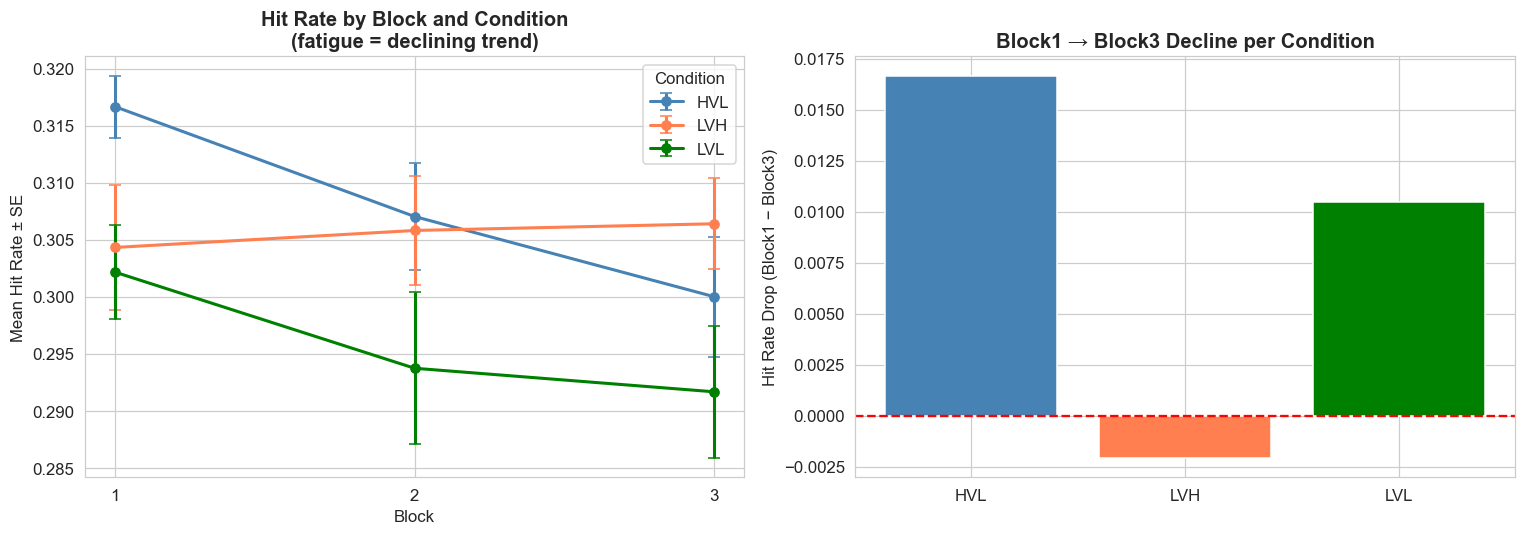

In [26]:
import os
from scipy.stats import friedmanchisquare

all_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.log')])

dfs_b = []
for fname in all_files:
    tmp = pd.read_csv(os.path.join(DATA_DIR, fname))
    tmp['source_file'] = fname
    dfs_b.append(tmp)

raw_b = pd.concat(dfs_b, ignore_index=True)

raw_b.columns = [c.strip() for c in raw_b.columns]
raw_b.replace({'N/A': np.nan}, inplace=True)

for col in [
    'Accuracy IR',
    'Accuracy WR',
    'Reaction_time_IR',
    'Reaction_time_WR'
]:
    raw_b[col] = pd.to_numeric(raw_b[col], errors='coerce')


# Parse condition/voice
def parse_stim(s):
    if pd.isna(s):
        return np.nan,np.nan

    p=str(s).strip().split('_')

    if len(p)>=3:
        return p[0],p[-1]

    return np.nan,np.nan


raw_b['condition'] = raw_b['Stimulus'].apply(
    lambda x: parse_stim(x)[0]
)

raw_b['voice'] = raw_b['Stimulus'].apply(
    lambda x: parse_stim(x)[1]
)


# Block assignment
def assign_blocks_fixed(df):

    df=df.copy().sort_values(
        ['participant_ID','Timestamp']
    ).reset_index(drop=True)

    bl=np.zeros(len(df),dtype=int)

    for pid,grp in df.groupby(
        'participant_ID',
        sort=False
    ):

        idx=grp.index.tolist()
        block=0
        inp=True

        for i in idx:

            ev=str(df.at[i,'Event'])

            if ev.startswith('Practice'):
                bl[i]=0

            elif ev=='Rest Phase started':
                block+=1
                bl[i]=block

            else:
                if inp and not ev.startswith('Practice'):
                    block=max(block,1)

                bl[i]=block

    df['block']=bl
    return df


raw_b=assign_blocks_fixed(raw_b)

valid_pairs=set(
    bv[bv['is_valid']]
      [['participant_ID','block']]
      .apply(tuple,axis=1)
)

def is_true(v):
    if pd.isna(v):
        return False
    return str(v).lower().strip()=='true'

raw_b['_ir']=raw_b['isRepeat'].apply(is_true)
raw_b['_it']=raw_b['isTarget'].apply(is_true)
raw_b['_iv']=raw_b['isValidation'].apply(is_true)

# Clean experimental trials

main_b = raw_b[
    (raw_b['block']>=1)
    &
    (~raw_b['Event'].astype(str).str.startswith('Practice',na=False))
    &
    (~raw_b['Event'].astype(str).str.contains('gap_time',na=False))
    &
    (~raw_b['Event'].astype(str).str.contains('Rest Phase',na=False))
].copy()

clean_b = main_b[
    main_b.apply(
      lambda r:
      (r['participant_ID'],r['block']) in valid_pairs,
      axis=1
    )
]

exp_b = clean_b[
    clean_b['condition'].isin(
        ['HVL','LVH','LVL']
    )
].copy()

# Block hit rate
def block_hit(grp):

    hits=(
      (
       grp['Event']=='IR pressed'
      )
      &
      grp['_ir']
      &
      ~grp['_iv']
      &
      (grp['Accuracy IR']==1)
    ).sum()

    n_t=(
      grp['_it']
      &
      grp['_ir']
      &
      ~grp['_iv']
    ).sum()

    return pd.Series({
        'hit_rate':
            hits/n_t if n_t>0 else np.nan,
        'n_targets':
            n_t
    })

block_cr_df=(
 exp_b
 .groupby(
   ['participant_ID','block','condition']
 )
 .apply(block_hit)
 .reset_index()
)

print('Block × Condition Hit Rate Table:')
print(
 block_cr_df
 .groupby(
   ['block','condition']
 )['hit_rate']
 .agg(
   Mean='mean',
   SE=lambda x:x.sem(),
   N='count'
 ).round(4).to_string()
)

norm_nh1 = normality_table(
    block_cr_df,
    'hit_rate',
    'condition',
    'Shapiro-Wilk Block Hit Rate'
)

# Friedman repeated measures tests + Kendall W

print('\n--- Friedman ANOVA: Block effect within each condition ---')

for cond in ['HVL','LVH','LVL']:

    sub = block_cr_df[
        block_cr_df['condition']==cond
    ]

    pivot_b = (
        sub.pivot_table(
            index='participant_ID',
            columns='block',
            values='hit_rate'
        )
        .dropna()
    )

    if pivot_b.shape[1] < 3:
        continue

    stat,p = friedmanchisquare(
        pivot_b[1],
        pivot_b[2],
        pivot_b[3]
    )

    n=len(pivot_b)
    k=3

    W=stat/(n*(k-1))

    print(
      f'{cond}: '
      f'χ²={stat:.4f}, '
      f'p={p:.4f} {sig(p)}, '
      f'Kendall W={W:.4f}'
    )

fig,axes=plt.subplots(
    1,2,
    figsize=(14,5)
)

for cond,col in zip(
 ['HVL','LVH','LVL'],
 ['steelblue','coral','green']
):

    sub=(
      block_cr_df[
       block_cr_df['condition']==cond
      ]
      .groupby('block')['hit_rate']
    )

    m=sub.mean()
    se=sub.sem()

    axes[0].errorbar(
        m.index,
        m.values,
        yerr=se.values,
        marker='o',
        linewidth=2,
        capsize=4,
        color=col,
        label=cond
    )

axes[0].set_xlabel('Block')
axes[0].set_ylabel('Mean Hit Rate ± SE')
axes[0].set_title(
'Hit Rate by Block and Condition\n(fatigue = declining trend)',
fontweight='bold'
)
axes[0].legend(title='Condition')
axes[0].set_xticks([1,2,3])


declines=[]

for cond in ['HVL','LVH','LVL']:

    sub=block_cr_df[
      block_cr_df['condition']==cond
    ]

    piv=sub.pivot_table(
        index='participant_ID',
        columns='block',
        values='hit_rate'
    )

    if 1 in piv.columns and 3 in piv.columns:
        declines.append({
          'condition':cond,
          'decline':piv[1].mean()-piv[3].mean()
        })

dec_df=pd.DataFrame(declines)

axes[1].bar(
 dec_df['condition'],
 dec_df['decline'],
 color=['steelblue','coral','green']
)

axes[1].axhline(
 0,
 color='red',
 linestyle='--'
)

axes[1].set_title(
'Block1 → Block3 Decline per Condition',
fontweight='bold'
)

axes[1].set_ylabel(
'Hit Rate Drop (Block1 − Block3)'
)

plt.tight_layout()
plt.show()

In [27]:
# ======================================================
# H6 Post-hoc Block Comparisons
# ======================================================

print('\n=== H6 Post-hoc Block Comparisons (Bonferroni) ===')

for cond in ['HVL','LVH','LVL']:

    print(f'\n{cond}')
    pivot_b = (
        block_cr_df[
            block_cr_df.condition==cond
        ].pivot_table(
            index='participant_ID',
            columns='block',
            values='hit_rate'
        ).dropna()
    )

    pairs=[
        (1,2),
        (1,3),
        (2,3)
    ]

    for a,b in pairs:
        W,p = wilcoxon(
            pivot_b[a],
            pivot_b[b]
        )

        p_b=min(p*3,1)

        print(
         f'Block {a} vs {b}: '
         f'W={W:.1f}, '
         f'p_bonf={p_b:.4f} '
         f'{sig(p_b)}'
        )


=== H6 Post-hoc Block Comparisons (Bonferroni) ===

HVL
Block 1 vs 2: W=460.0, p_bonf=0.3442 ns
Block 1 vs 3: W=475.0, p_bonf=0.0123 *
Block 2 vs 3: W=514.0, p_bonf=0.6684 ns

LVH
Block 1 vs 2: W=696.0, p_bonf=1.0000 ns
Block 1 vs 3: W=637.5, p_bonf=1.0000 ns
Block 2 vs 3: W=710.0, p_bonf=1.0000 ns

LVL
Block 1 vs 2: W=801.0, p_bonf=1.0000 ns
Block 1 vs 3: W=755.0, p_bonf=0.4913 ns
Block 2 vs 3: W=718.5, p_bonf=0.6103 ns


## H5: Condition Effect on False Alarm Rate (Response Bias)

In [28]:
print('\nDescriptive FA rate by condition:')
desc_fa = cr_long.groupby('cond_voice')['fa_rate'].agg(
    N='count', Mean='mean', Median='median', SD='std',
    SE=lambda x:x.sem(),
    Pct_zero=lambda x:(x==0).mean()*100).round(4)
print(desc_fa.to_string())

fa_wide = cr_long.pivot_table(index='participant_ID', columns='cond_voice', values='fa_rate')
fa_wide['HVL'] = fa_wide[['HVL_A','HVL_P']].mean(axis=1)
fa_wide['LVH'] = fa_wide[['LVH_A','LVH_P']].mean(axis=1)
fa_wide['LVL'] = fa_wide[['LVL_A','LVL_P']].mean(axis=1)
fa_cond = fa_wide[['HVL','LVH','LVL']].dropna()

print('\n--- Friedman Test: Condition effect (HVL vs LVH vs LVL) ---')

chi2,p = friedmanchisquare(
    fa_cond['HVL'],
    fa_cond['LVH'],
    fa_cond['LVL']
)

n=len(fa_cond)
k=3
W=chi2/(n*(k-1))

print(
f'Friedman χ²={chi2:.4f}, '
f'p={p:.4f} {sig(p)}'
)
print(
f"Kendall's W={W:.4f}"
)
print('\n--- Post-hoc Wilcoxon (Bonferroni corrected) ---')

pairs=[
 ('HVL','LVH'),
 ('HVL','LVL'),
 ('LVH','LVL')
]

for g1,g2 in pairs:

    d=fa_cond[[g1,g2]].dropna()

    W,p_val=wilcoxon(
        d[g1],
        d[g2]
    )

    p_b=min(
      p_val*3,
      1
    )

    print(
      f'{g1} vs {g2}: '
      f'W={W:.2f}, '
      f'p_bonf={p_b:.4f} '
      f'{sig(p_b)}'
    )

fa_wide['Active']  = fa_wide[['HVL_A','LVH_A','LVL_A']].mean(axis=1)
fa_wide['Passive'] = fa_wide[['HVL_P','LVH_P','LVL_P']].mean(axis=1)
fa_voice = fa_wide[['Active','Passive']].dropna()

print('\n--- Wilcoxon: Voice effect (Active vs Passive) ---')
W_v, p_v = wilcoxon(fa_voice['Active'], fa_voice['Passive'])
print(f'Active vs Passive: W={W_v:.2f}, p={p_v:.4f} {sig(p_v)}')


Descriptive FA rate by condition:
              N   Mean  Median     SD     SE  Pct_zero
cond_voice                                            
HVL_A       112 0.0714  0.0000 0.1078 0.0102   65.1786
HVL_P       112 0.0573  0.0000 0.0943 0.0089   70.5357
LVH_A       112 0.0268  0.0000 0.0615 0.0058   83.9286
LVH_P       112 0.0238  0.0000 0.0586 0.0055   85.7143
LVL_A       112 0.0268  0.0000 0.0727 0.0069   86.6071
LVL_P       112 0.0454  0.0000 0.1012 0.0096   79.4643

--- Friedman Test: Condition effect (HVL vs LVH vs LVL) ---
Friedman χ²=22.2060, p=0.0000 ***
Kendall's W=0.0991

--- Post-hoc Wilcoxon (Bonferroni corrected) ---
HVL vs LVH: W=222.00, p_bonf=0.0000 ***
HVL vs LVL: W=539.50, p_bonf=0.0028 **
LVH vs LVL: W=328.00, p_bonf=0.3124 ns

--- Wilcoxon: Voice effect (Active vs Passive) ---
Active vs Passive: W=1154.50, p=0.9075 ns


## H7: Effect of Voice on Reaction Time (RT_IR)


Descriptive Statistics:
         N      Mean    Median       SD      SE   CI95_lo   CI95_hi
voice                                                              
A      333 1683.7230 1633.0000 387.1450 21.2150 1642.1410 1725.3060
P      334 1758.0490 1697.8330 417.5540 22.8480 1713.2680 1802.8300

Shapiro-Wilk on Active-Passive RT differences: W=0.9702, p=0.0133 --> Non-normal -- Wilcoxon used

Wilcoxon Signed-Rank: W=2086.0, p=0.0018 **, r=0.341
  Mean RT Active  = 1685.15 ms
  Mean RT Passive = 1761.10 ms
  Direction: Active < Passive

RT_IR by Voice within each Memorability Condition (Wilcoxon + Bonferroni, 3 tests):
Condition  W          p_raw        p_bonf       sig    RT_Active      RT_Passive
--------------------------------------------------------------------------
HVL        1866.0     0.0003       0.0008       ***    1660.32        1795.48
LVH        3012.0     0.9039       1.0000       ns     1668.90        1658.39
LVL        2181.0     0.0136       0.0407       *      1717.1

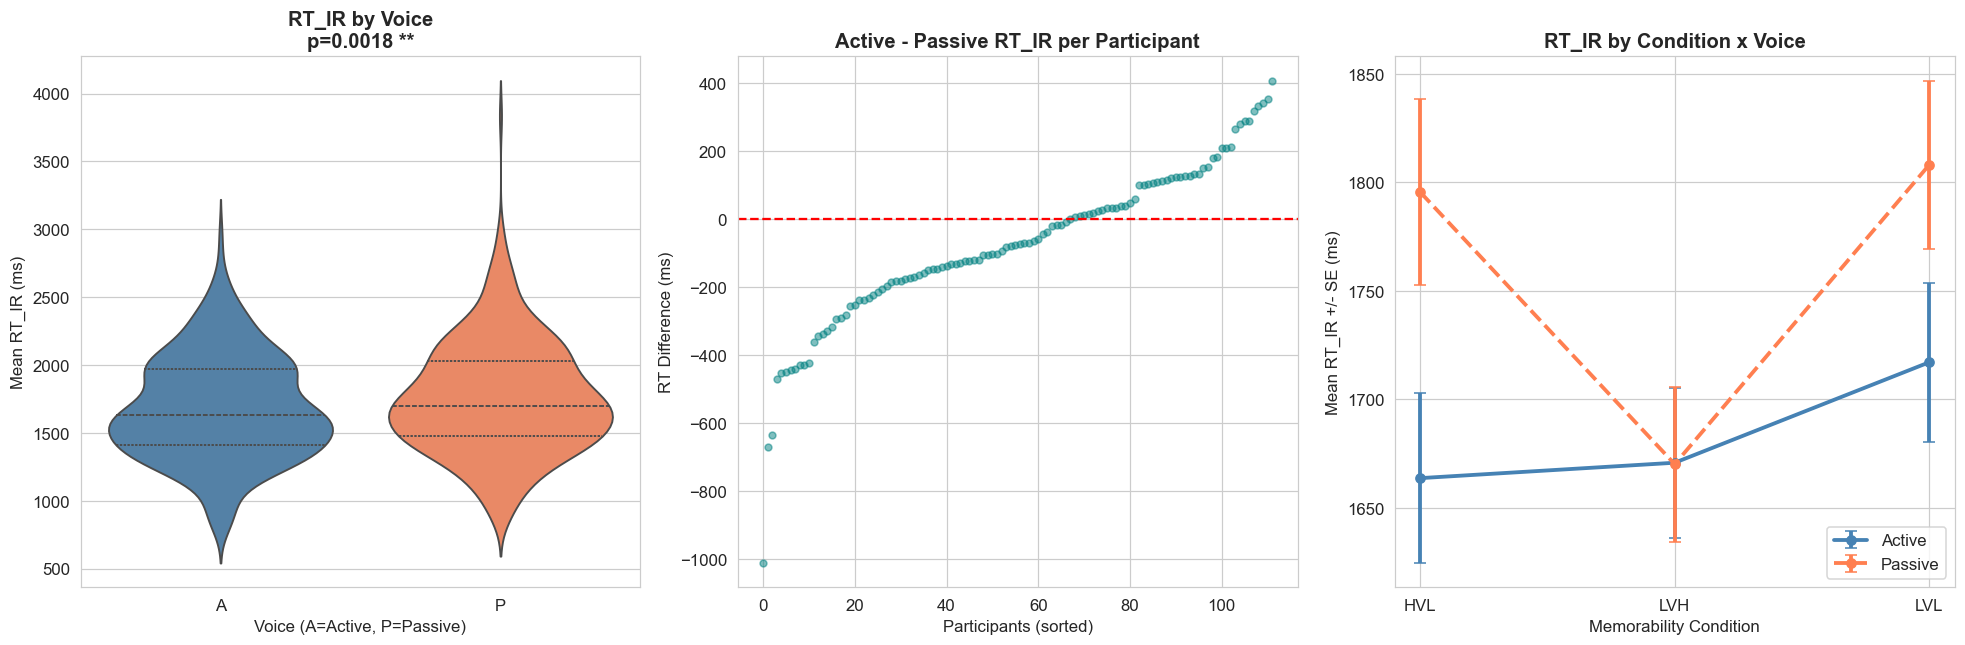

In [29]:
# Derive participant-level RT per voice
rt_voice_wide = cr_long.pivot_table(
    index='participant_ID', columns='voice',
    values='mean_rt_ir_clean', aggfunc='mean')
rt_voice_wide.columns.name = None
rt_voice_wide = rt_voice_wide.rename(columns={'A': 'RT_Active', 'P': 'RT_Passive'})
rt_voice_wide['diff_RT_A_minus_P'] = rt_voice_wide['RT_Active'] - rt_voice_wide['RT_Passive']

print('\nDescriptive Statistics:')
desc_h5 = cr_long.groupby('voice')['mean_rt_ir_clean'].agg(
    N='count', Mean='mean', Median='median', SD='std',
    SE=lambda x: x.sem(),
    CI95_lo=lambda x: x.mean() - 1.96 * x.sem(),
    CI95_hi=lambda x: x.mean() + 1.96 * x.sem()).round(3)
print(desc_h5.to_string())

# Normality of differences
diff_rt = rt_voice_wide['diff_RT_A_minus_P'].dropna()
w_h5, p_h5_norm = shapiro(diff_rt)
print(f'\nShapiro-Wilk on Active-Passive RT differences: W={w_h5:.4f}, p={p_h5_norm:.4f}'
      f' --> {"Normal" if p_h5_norm > 0.05 else "Non-normal -- Wilcoxon used"}')

common_h5 = rt_voice_wide.dropna(subset=['RT_Active', 'RT_Passive'])
if p_h5_norm > 0.05:
    from scipy.stats import ttest_rel
    t_h5, p_h5 = ttest_rel(common_h5['RT_Active'], common_h5['RT_Passive'])
    d_h5 = cohens_d_paired(common_h5['RT_Active'], common_h5['RT_Passive'])
    print(f'\nH5a -- Paired t-test: t={t_h5:.4f}, p={p_h5:.4f} {sig(p_h5)}, Cohen d={d_h5:.3f}')
else:
    W_h5, p_h5 = wilcoxon(common_h5['RT_Active'], common_h5['RT_Passive'])
    r_h5 = wilcoxon_r(W_h5, len(common_h5))
    print(f'\nWilcoxon Signed-Rank: W={W_h5:.1f}, p={p_h5:.4f} {sig(p_h5)}, r={r_h5:.3f}')

print(f'  Mean RT Active  = {common_h5["RT_Active"].mean():.2f} ms')
print(f'  Mean RT Passive = {common_h5["RT_Passive"].mean():.2f} ms')
direction = 'Active > Passive' if common_h5['RT_Active'].mean() > common_h5['RT_Passive'].mean() else 'Active < Passive'
print(f'  Direction: {direction}')

# Voice within each Condition
print('\nRT_IR by Voice within each Memorability Condition (Wilcoxon + Bonferroni, 3 tests):')
print(f'{"Condition":<10} {"W":<10} {"p_raw":<12} {"p_bonf":<12} {"sig":<6} {"RT_Active":<14} {"RT_Passive"}')
print('-'*74)
for cond in TARGET_CONDITIONS:
    sub = cr_long[cr_long['condition'] == cond]
    act_rt = sub[sub['voice'] == 'A'].set_index('participant_ID')['mean_rt_ir_clean']
    pas_rt = sub[sub['voice'] == 'P'].set_index('participant_ID')['mean_rt_ir_clean']
    m_rt = pd.concat([act_rt, pas_rt], axis=1, keys=['A', 'P']).dropna()
    if len(m_rt) < 8: continue
    W_c, p_c = wilcoxon(m_rt['A'], m_rt['P'])
    p_b = min(p_c * 3, 1.0)
    print(f'{cond:<10} {W_c:<10.1f} {p_c:<12.4f} {p_b:<12.4f} {sig(p_b):<6} {m_rt["A"].mean():<14.2f} {m_rt["P"].mean():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.violinplot(data=cr_long, x='voice', y='mean_rt_ir_clean',
               ax=axes[0], palette=['steelblue', 'coral'], inner='quartile')
axes[0].set_title(f'RT_IR by Voice\np={p_h5:.4f} {sig(p_h5)}', fontweight='bold')
axes[0].set_xlabel('Voice (A=Active, P=Passive)'); axes[0].set_ylabel('Mean RT_IR (ms)')

axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].scatter(range(len(diff_rt)), diff_rt.sort_values(), alpha=0.5, color='teal', s=20)
axes[1].set_title('Active - Passive RT_IR per Participant', fontweight='bold')
axes[1].set_xlabel('Participants (sorted)'); axes[1].set_ylabel('RT Difference (ms)')

rt_int = cr_long.groupby(['condition', 'voice'])['mean_rt_ir_clean'].agg(
    mean='mean', sem=lambda x: x.sem()).reset_index()
for v, ls, col in [('A', '-', 'steelblue'), ('P', '--', 'coral')]:
    sub = rt_int[rt_int['voice'] == v]
    axes[2].errorbar(sub['condition'], sub['mean'], yerr=sub['sem'],
                     linestyle=ls, marker='o', capsize=4, linewidth=2.5,
                     color=col, label='Active' if v == 'A' else 'Passive')
axes[2].legend(); axes[2].set_title('RT_IR by Condition x Voice', fontweight='bold')
axes[2].set_xlabel('Memorability Condition'); axes[2].set_ylabel('Mean RT_IR +/- SE (ms)')
plt.tight_layout(); plt.show()

p_h5_final = p_h5